In [ ]:
import os
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import scipy.sparse as sp
import pandas as pd
from tqdm.notebook import tqdm

from rdkit.Chem import rdFingerprintGenerator

from chemap import metrics
from chemap.fingerprint_computation import compute_fingerprints, FingerprintConfig

ROOT = Path(os.getcwd()).parents[0]

In [2]:
from chemap.fingerprint_conversions import fingerprints_to_csr

In [3]:
path_data = r"/home/daisy/Florian/chemical_datasets/fingerprint_benchmarking"
compounds = pd.read_csv(os.path.join(path_data, "25_subclasses_chemical_subset.csv"))
compounds

,inchikey,SMILES,Kingdom,Superclass,Class,Subclass,mass
0,QKAAFOFCOXIVQV-UHFFFAOYSA-N,CCC(C)C1C(=O)NC(C(=O)N2CCCC2C(=O)NC(C(=O)N3CCC...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",828.024
1,GXENQLUSOCKXDN-UHFFFAOYSA-N,CC(C)CC(C(=O)NC1CN(CC1=O)C(=O)C(CC(C)C)NC(=O)O...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",594.709
2,UFUVLHLTWXBHGZ-MGZQPHGTSA-N,CCCC1CC(N(C1)C)C(=O)NC(C2C(C(C(C(O2)SC)OP(=O)(...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",504.970
3,NXVSIVOMSMWEAU-UHFFFAOYSA-N,CC(C)C(C(=O)O)NC(=O)C1CSSCC(C(=O)NC(C(=O)NC(C(...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",1075.281
4,UOKQCKCIJOFELB-UHFFFAOYSA-N,CC(C(=O)NC(CCC(=O)N)C(=O)NC(CCCN=C(N)N)C(=O)NC...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",708.667
...,...,...,...,...,...,...,...
74995,QWSUTGZKTVZPRT-UHFFFAOYSA-N,C1=CC=C(C=C1)CC2=CC=CC=C2CCN,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,211.308
74996,JYHNHWMZIXPAEL-UHFFFAOYSA-N,C1=CC=C(C=C1)C(CCC#N)C2=CC=CC=C2,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,221.303
74997,MSYLETHDEIJMAF-UHFFFAOYSA-N,C1=CC=C(C=C1)C(C2=CC=CC=C2)C(=O)Cl,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,230.694
74998,DRCFCSOWKZBHDM-UHFFFAOYSA-N,CCOC(=O)COC1=CC=C(C=C1)CC2=CC=CC=C2,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,270.328


In [4]:
compounds.value_counts("Subclass")

Subclass
1-benzopyrans                                3000
Amines                                       3000
Amino acids, peptides, and analogues         3000
Anilides                                     3000
Benzodiazines                                3000
Benzoic acids and derivatives                3000
Carbohydrates and carbohydrate conjugates    3000
Carbonyl compounds                           3000
Diphenylmethanes                             3000
Diterpenoids                                 3000
Ethers                                       3000
Fatty acid esters                            3000
Fatty acids and conjugates                   3000
Flavonoid glycosides                         3000
Halobenzenes                                 3000
Monoterpenoids                               3000
Piperazines                                  3000
Pyrazoles                                    3000
Pyridoindoles                                3000
Pyrimidines and pyrimidine derivatives   

## Define experiments

In [ ]:
# import fingerprint algorithms
from chemap.fingerprints import MAP4FPGen
from chemap.fingerprints import LingoFingerprint

from rdkit.Chem import rdFingerprintGenerator
from skfp.fingerprints import (
    MACCSFingerprint,
    PubChemFingerprint,
    KlekotaRothFingerprint,
    AvalonFingerprint,
)

In [6]:
from chemap.fingerprints import ElementCountFingerprint

baseline = ElementCountFingerprint(
    elements=["H","C","N","O","P","S","F","Cl","Br","I"],
    include_hs="implicit",
    unknown_policy="other",   # adds "Other" as last dim
    sparse=False,
    n_jobs=8,
)

In [7]:
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence

import numpy as np
import scipy.sparse as sp
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin

from biosynfoni import Biosynfoni


class BiosynfoniTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-style wrapper around Biosynfoni.

    Inputs to fit/transform: Sequence[rdkit.Chem.Mol]
    Output:
      - variant="folded": (N, D) dense float32 or CSR float32 (if sparse=True)
      - variant="raw_bits": same as above; chemap will convert to unfolded if cfg.folded=False
        (for Biosynfoni, raw feature space is already 0..D-1, so "raw_bits" == "folded")
    """

    def __init__(
        self,
        *,
        sparse: bool = False,
        variant: str = "folded",   # chemap may set this to "raw_bits"
        n_jobs: int = 1,
        verbose: int = 0,
    ):
        self.sparse = sparse
        self.variant = variant
        self.n_jobs = n_jobs
        self.verbose = verbose

    def fit(self, X: Sequence[Any], y: Any = None) -> "BiosynfoniTransformer":
        # No training needed, but sklearn expects fit() to exist.
        return self

    def transform(self, X: Sequence[Any]):
        # X is expected to be a list of RDKit mols (some may be None depending on your mol pipeline)
        def fp_row(mol) -> np.ndarray:
            if mol is None:
                # let chemap decide what to do with invalids; here we return empty and let caller handle
                return np.array([], dtype=np.float32)
            arr = np.asarray(Biosynfoni(mol).fingerprint, dtype=np.float32)
            return arr

        rows: List[np.ndarray] = Parallel(n_jobs=self.n_jobs)(
            delayed(fp_row)(mol) for mol in X
        )

        # Infer D from first non-empty row
        D = next((r.shape[0] for r in rows if r.size), 0)

        # Backfill empties to keep rectangular output (chemap currently passes only valid mols,
        # but this also makes the transformer robust if you change that later)
        for i, r in enumerate(rows):
            if r.size == 0 and D:
                rows[i] = np.zeros((D,), dtype=np.float32)

        X_dense = np.vstack(rows).astype(np.float32, copy=False) if rows else np.zeros((0, D), dtype=np.float32)

        if not self.sparse:
            return X_dense

        return sp.csr_matrix(X_dense, dtype=np.float32)


In [ ]:
import os
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import pandas as pd
import scipy.sparse as sp
import numba as nb
import pynndescent


def ensure_pynndescent_csr(X: sp.csr_matrix) -> sp.csr_matrix:
    X = X.tocsr(copy=False)
    X.sum_duplicates()
    X.sort_indices()

    # keep values compact
    if X.data.dtype != np.float32:
        X.data = X.data.astype(np.float32, copy=False)

    if X.indices.dtype != np.int32:
        X.indices = X.indices.astype(np.int32, copy=False)

    # CRITICAL: keep indptr int64 for PyNNDescent sparse routines
    if X.indptr.dtype != np.int64:
        X.indptr = X.indptr.astype(np.int64, copy=False)

    return X

# -----------------------------
# Evaluation
# -----------------------------
def _strip_self_neighbors(knn_idx: np.ndarray, knn_dist: Optional[np.ndarray] = None) -> tuple[np.ndarray, Optional[np.ndarray]]:
    """
    If the first neighbor is the point itself, drop it (row-wise) and shift left.
    Keeps shape (n, k-1) if it removed self from every row; otherwise returns original.
    """
    n, k = knn_idx.shape
    self_mask = (knn_idx[:, 0] == np.arange(n))
    if not np.all(self_mask):
        # Mixed behavior; leave as-is but you can handle this if needed.
        return knn_idx, knn_dist

    knn_idx2 = knn_idx[:, 1:]
    if knn_dist is None:
        return knn_idx2, None
    return knn_idx2, knn_dist[:, 1:]


def evaluate_knn_label_match_fractions(
    labels: np.ndarray,
    knn_idx: np.ndarray,
    *,
    ks: Sequence[int],
    ignore_nan_query: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute:
      - overall mean same-label fraction for each k in ks
      - per-class mean same-label fraction for each k in ks

    Returns:
      overall_df: columns [k, mean_same_class_pct]
      per_class_df: columns [label, k, mean_same_class_pct]
    """
    if knn_idx.ndim != 2:
        raise ValueError("knn_idx must be a 2D array (n, K).")

    n, K = knn_idx.shape
    ks = list(ks)
    if any(k < 1 or k > K for k in ks):
        raise ValueError(f"All ks must be within [1, {K}] for this knn index array.")

    labels = np.asarray(labels)
    query = labels[:, None]         # (n, 1)
    neigh = labels[knn_idx]         # (n, K)

    # matches: NaNs won't match anything (including NaN), which is what we want for neighbors
    matches = (neigh == query)      # (n, K) bool

    # Cumulative mean for all k: (n, K)
    csum = np.cumsum(matches, axis=1, dtype=np.int32)
    denom = np.arange(1, K + 1, dtype=np.float32)[None, :]
    frac_all = csum / denom  # (n, K), float

    # Optionally ignore NaN query labels (set those rows to NaN)
    if ignore_nan_query:
        q_is_nan = pd.isna(labels)
        frac_all = frac_all.astype(np.float32, copy=False)
        frac_all[q_is_nan, :] = np.nan

    # Overall means for requested ks
    overall_rows = []
    for k in ks:
        vals = frac_all[:, k - 1]
        mean = np.nanmean(vals) * 100.0
        overall_rows.append({"k": k, "mean_same_class_pct": float(mean)})
    overall_df = pd.DataFrame(overall_rows)

    # Per-class means for requested ks
    per_class_rows = []
    valid_query = ~pd.isna(labels) if ignore_nan_query else np.ones(n, dtype=bool)
    unique_labels = pd.unique(labels[valid_query])

    for lab in unique_labels:
        mask = valid_query & (labels == lab)
        if not np.any(mask):
            continue
        for k in ks:
            vals = frac_all[mask, k - 1]
            mean = np.nanmean(vals) * 100.0
            per_class_rows.append({"label": lab, "k": k, "mean_same_class_pct": float(mean)})

    per_class_df = pd.DataFrame(per_class_rows)
    return overall_df, per_class_df


# -----------------------------
# Variant definitions
# -----------------------------
@dataclass(frozen=True)
class Variant:
    name: str
    # how to transform unfolded fingerprints into an ANN input matrix
    mode: str  # "count_sparse"|"tfidf_sparse"|"count_fold_dense"|"tfidf_fold_dense"
    min_occurrence: Optional[int] = None
    max_occurrence: Optional[float | int] = None
    fold_to: Optional[int] = None  # e.g. 4096





# -----------------------------
# Glue: build matrices for variants
# -----------------------------
def build_ann_matrix_for_variant(
    unfolded_fps,
    variant: Variant,
):
    """
    Returns:
      X_ann: csr_matrix or ndarray (dense)
      metric: callable for PyNNDescent
      metric_is_sparse: bool
    Notes:
      - Assumes unfolded_fps are count-unfolded (bits,counts) or bit-only arrays.
      - Uses your refactored library functions from the previous message.
    """

    if variant.mode == "count_sparse":
        out = fingerprints_to_csr(
            unfolded_fps,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    if variant.mode == "tfidf_sparse":
        out = fingerprints_to_tfidf(
            unfolded_fps,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    if variant.mode == "count_fold_dense":
        if variant.fold_to is None:
            raise ValueError("fold_to must be set for folded variants.")
        out = fingerprints_to_csr_folded(
            unfolded_fps,
            n_folded_features=variant.fold_to,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X.toarray().astype(np.float32, copy=False)
        return X, tanimoto_distance_dense, False

    if variant.mode == "tfidf_fold_dense":
        if variant.fold_to is None:
            raise ValueError("fold_to must be set for folded variants.")
        out = fingerprints_to_tfidf_folded(
            unfolded_fps,
            n_folded_features=variant.fold_to,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X.toarray().astype(np.float32, copy=False)
        return X, tanimoto_distance_dense, False

    if variant.mode == "log_count_sparse":
        out = fingerprints_to_csr(
            [(x, np.log(1 + y)) for (x, y) in unfolded_fps],
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    if variant.mode == "log_count":
        return np.log(1 + unfolded_fps), tanimoto_distance_dense, False

    if variant.mode == "count_dense":
        return unfolded_fps, tanimoto_distance_dense, False

    if variant.mode == "tfidf_dense":
        bit_weighing = idf_normalized((unfolded_fps > 0).sum(axis=0), len(unfolded_fps))
        fps_tfidf = unfolded_fps * bit_weighing
        return fps_tfidf, tanimoto_distance_dense, False
        
    raise ValueError(f"Unknown variant mode: {variant.mode}")



In [9]:
# ------------------------
# Define experiments
# ------------------------
invgen = rdFingerprintGenerator.GetMorganFeatureAtomInvGen()  # == useFeatures=True
    
FP_SIZE = 4096  # for all fingerprints with variable bit sizes

experiments = [   
    # --- Morgan / ECFP (RDKit generators) ---
    ("morgan3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), False),
    ("morgan3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True),

    ("morgan9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True),
    ("morgan9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), False),
    ("fcfp3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    ("fcfp9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    
    # --- path-based fingerprint (RDKitFP) ---
    ("rdkit_binary", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), False),
    ("rdkit_count", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), True),
    ("avalon_binary", AvalonFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("avalon_count", AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),
    
    # --- Complementary classic hashed fingerprints via RDKit generators ---
    # Atom Pair + Topological Torsion are standard alternatives to circular fingerprints
    ("atompair_binary", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), False),
    ("atompair_count", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True),
    ("ttorsion_binary", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), False),
    ("ttorsion_count", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True),

    # String based
    ("lingo_binary", LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("lingo_count", LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),              
    
    # map4 
    ("map4_binary", MAP4FPGen(dimensions=FP_SIZE, radius=2), False),
    ("map4_count", MAP4FPGen(dimensions=FP_SIZE, radius=2), True),
    
    # defined feature fingerprints
    ("maccs_binary", MACCSFingerprint(count=False, sparse=False), False),
    ("maccs_count", MACCSFingerprint(count=True, sparse=False), True),
    ("pubchem_binary", PubChemFingerprint(count=False, sparse=False), False),
    ("pubchem_count", PubChemFingerprint(count=True, sparse=False), True),
    ("klekotaroth_binary", KlekotaRothFingerprint(count=False, sparse=False), False),
    ("klekotaroth_count", KlekotaRothFingerprint(count=True, sparse=False), True),
    ("biosynfoni_count", BiosynfoniTransformer(sparse=False, n_jobs=-1), True),
]

# Implement experiments

In [ ]:


from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import pandas as pd
import scipy.sparse as sp
import pynndescent
from chemap.fingerprint_computation import _looks_like_rdkit_fpgen

# ------------------------
# Variant definitions
# ------------------------

@dataclass(frozen=True)
class Variant:
    name: str
    mode: str
    fold_to: Optional[int] = None
    min_occurrence: int = 1
    max_occurrence: int = 10**18


FIXED_SIZED_FPS = ["maccs", "pubchem", "klekotaroth", "biosynfoni", "element"]


def _fp_is_fixed_sized(fp_name: str) -> bool:
    n = fp_name.lower()
    return any(key in n for key in FIXED_SIZED_FPS)


def _supports_chemap_unfolded(fpgen: Any) -> bool:
    if _looks_like_rdkit_fpgen(fpgen):
        return True
    if hasattr(fpgen, "get_params"):
        try:
            params = fpgen.get_params(deep=False)
            return "folded" in params
        except Exception:
            return hasattr(fpgen, "folded")
    return hasattr(fpgen, "folded")


# ------------------------
# Variant selection
# ------------------------

def select_variants_for_fingerprint(
    fp_name: str,
    is_count_fp: bool,
    fpgen: Any,
    fp_size: int,
) -> List[Variant]:
    """
    Rules:
    - Count fingerprints: count_fold_dense + log_count_fold_dense + tfidf_fold_dense always
      and, if (not fixed-sized AND chemap-unfolded) also: count_sparse + log_count_sparse + tfidf_sparse
    - Binary fingerprints:
      - if (not fixed-sized AND chemap-unfolded): binary_sparse
      - else: binary_fold_dense
    """
    variants: List[Variant] = []

    # define needed variants
    binary_fold_dense = Variant("binary_fold_dense", "binary_fold_dense", fold_to=fp_size)
    binary_sparse = Variant("binary_sparse", "binary_sparse")

    count_fold_dense = Variant("count_fold_dense", "count_fold_dense", fold_to=fp_size)
    log_count_fold_dense = Variant("log_count_fold_dense", "log_count_fold_dense", fold_to=fp_size)
    tfidf_fold_dense = Variant("tfidf_fold_dense", "tfidf_fold_dense", fold_to=fp_size)

    count_sparse = Variant("count_sparse", "count_sparse")
    log_count_sparse = Variant("log_count_sparse", "log_count_sparse")
    tfidf_sparse = Variant("tfidf_sparse", "tfidf_sparse")

    if is_count_fp:
        variants += [count_fold_dense, log_count_fold_dense, tfidf_fold_dense]
        if (not _fp_is_fixed_sized(fp_name)) and _supports_chemap_unfolded(fpgen):
            variants += [count_sparse, log_count_sparse, tfidf_sparse]
        return variants

    # binary fingerprints
    if (not _fp_is_fixed_sized(fp_name)) and _supports_chemap_unfolded(fpgen):
        variants.extend([binary_fold_dense, binary_sparse])
    else:
        variants.append(binary_fold_dense)

    return variants


# ------------------------
# Minimal representations
# ------------------------

@dataclass
class FingerprintCache:
    folded_dense: Optional[np.ndarray] = None   # (N, D) float32 for ANN
    unfolded: Optional[Any] = None              # chemap unfolded formats (binary or count)


def compute_needed_fingerprints_for_fp(
    smiles: Sequence[str],
    fpgen: Any,
    fp_name: str,
    is_count_fp: bool,
    variants: Sequence[Variant],
    *,
    show_progress: bool,
    n_jobs: int,
) -> FingerprintCache:
    """
    Compute only what is necessary for the chosen variants.
    Works for count and binary.

    Folded dense is computed when any *_fold_dense variant is requested.
    Unfolded is computed when any *_sparse variant is requested.
    """
    cache = FingerprintCache()

    folded_modes = {"count_fold_dense", "log_count_fold_dense", "tfidf_fold_dense", "binary_fold_dense"}
    sparse_modes = {"count_sparse", "log_count_sparse", "tfidf_sparse", "binary_sparse"}

    need_folded = any(v.mode in folded_modes for v in variants)
    need_unfolded = any(v.mode in sparse_modes for v in variants)

    if need_folded:
        # compute folded vector/matrix for ANN; count flag depends on experiment
        X = compute_fingerprints(
            smiles,
            fpgen,
            config=FingerprintConfig(
                count=bool(is_count_fp),
                folded=True,
                return_csr=False,
                invalid_policy="raise",
            ),
            show_progress=show_progress,
            n_jobs=n_jobs,
        )
        # float32 is fine for ANN distances
        cache.folded_dense = np.asarray(X, dtype=np.float32)

    if need_unfolded:
        if not _supports_chemap_unfolded(fpgen):
            raise ValueError(f"{fp_name}: sparse variants requested but fpgen has no chemap-unfolded support")

        cache.unfolded = compute_fingerprints(
            smiles,
            fpgen,
            config=FingerprintConfig(
                count=bool(is_count_fp),
                folded=False,
                invalid_policy="raise",
            ),
            show_progress=show_progress,
            n_jobs=n_jobs,
        )

    return cache


# ------------------------
# Main benchmark loop
# ------------------------

def run_benchmark_scan(
    compounds: pd.DataFrame,
    label_col: str,
    smiles_col: str,
    experiments: Dict[str, Tuple[Any, bool]],  # fp_name -> (fpgen, is_count_fp)
    *,
    results_path: str,
    fp_size: int,
    K: int,
    ks: Sequence[int],
    random_state: int = 0,
    show_progress: bool = True,
    n_jobs: int = -1,
) -> pd.DataFrame:
    labels = compounds[label_col].to_numpy()
    smiles = compounds[smiles_col].to_list()

    if os.path.exists(results_path):
        results_df = pd.read_csv(results_path)
    else:
        results_df = pd.DataFrame(
            columns=[
                "fingerprint",
                "variant",
                "unfolded",
                "K",
                "k",
                "scope",
                "label",
                "mean_same_class_pct",
            ]
        )

    folded_modes = {"count_fold_dense", "log_count_fold_dense", "tfidf_fold_dense", "binary_fold_dense"}
    sparse_modes = {"count_sparse", "log_count_sparse", "tfidf_sparse", "binary_sparse"}

    for fp_name, (fpgen, is_count_fp) in experiments.items():
        print(f"\n=== Fingerprint: {fp_name} (is_count_fp={is_count_fp}) ===")

        variants = select_variants_for_fingerprint(fp_name, is_count_fp, fpgen, fp_size=fp_size)
        if not variants:
            print(f"  (skip) no variants selected for {fp_name}")
            continue

        pending_variants: List[Variant] = []
        for v in variants:
            existing = results_df[
                (results_df["fingerprint"] == fp_name)
                & (results_df["variant"] == v.name)
                & (results_df["K"] == K)
            ]
            if existing.empty:
                pending_variants.append(v)
                continue

            overall_existing = existing[existing["scope"] == "overall"]
            per_class_existing = existing[existing["scope"] == "per_class"]

            done_overall = set(overall_existing["k"].astype(int).tolist())
            done_per_class = set(per_class_existing["k"].astype(int).tolist())

            if set(ks).issubset(done_overall) and set(ks).issubset(done_per_class):
                # fully done
                continue

            pending_variants.append(v)

        if not pending_variants:
            print(f"  (skip) all variants already completed for {fp_name}")
            continue

        variants = pending_variants  # only run what is missing
        cache = compute_needed_fingerprints_for_fp(
            smiles,
            fpgen,
            fp_name,
            is_count_fp,
            variants,
            show_progress=show_progress,
            n_jobs=n_jobs,
        )

        for variant in variants:
            print(f"  -> Variant: {variant.name}")

            if variant.mode in folded_modes:
                fps_for_variant = cache.folded_dense
                unfolded_flag = False
                if fps_for_variant is None:
                    raise RuntimeError(f"{fp_name}: missing folded_dense for {variant.name}")

            elif variant.mode in sparse_modes:
                fps_for_variant = cache.unfolded
                unfolded_flag = True
                if fps_for_variant is None:
                    raise RuntimeError(f"{fp_name}: missing unfolded for {variant.name}")

            else:
                raise ValueError(f"Unknown variant mode: {variant.mode}")

            X_ann, metric, is_sparse = build_ann_matrix_for_variant(fps_for_variant, variant)

            if is_sparse:
                X_ann = ensure_pynndescent_csr(X_ann)

            index = pynndescent.NNDescent(
                X_ann,
                metric=metric,
                n_neighbors=K + 1,
                n_jobs=-1,
                random_state=random_state,
                tree_init=False,
                pruning_degree_multiplier=1.0,
                max_candidates=30,
                n_trees=8,
                leaf_size=40,
                low_memory=True,
            )
            knn_indices, knn_dists = index.neighbor_graph
            knn_indices, _ = _strip_self_neighbors(knn_indices, knn_dists)

            if knn_indices.shape[1] < max(ks):
                raise RuntimeError(
                    f"{fp_name}/{variant.name}: only {knn_indices.shape[1]} neighbors after stripping self, "
                    f"need at least {max(ks)}"
                )

            overall_df, per_class_df = evaluate_knn_label_match_fractions(
                labels,
                knn_indices[:, : max(ks)],
                ks=ks,
                ignore_nan_query=True,
            )

            rows = []
            for _, r in overall_df.iterrows():
                rows.append(
                    dict(
                        fingerprint=fp_name,
                        variant=variant.name,
                        unfolded=unfolded_flag,
                        K=K,
                        k=int(r["k"]),
                        scope="overall",
                        label=None,
                        mean_same_class_pct=float(r["mean_same_class_pct"]),
                    )
                )
            for _, r in per_class_df.iterrows():
                rows.append(
                    dict(
                        fingerprint=fp_name,
                        variant=variant.name,
                        unfolded=unfolded_flag,
                        K=K,
                        k=int(r["k"]),
                        scope="per_class",
                        label=r["label"],
                        mean_same_class_pct=float(r["mean_same_class_pct"]),
                    )
                )

            results_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)
            results_df.to_csv(results_path, index=False)
            print(f"     saved -> {results_path} (rows={len(results_df)})")

    return results_df


def idf_normalized(df: np.ndarray, N: int) -> np.ndarray:
    df = np.asarray(df, dtype=np.float64)
    if N < 1:
        raise ValueError("N must be >= 1.")
    if df.size == 0:
        return df.astype(np.float32)

    df = np.maximum(df, 1.0)
    max_idf = np.log(N / 1.0)
    if max_idf == 0.0:
        return np.zeros(df.shape[0], dtype=np.float32)
    return (np.log(N / df) / max_idf).astype(np.float32)


In [12]:
path_results = os.path.join(Path(ROOT), "experiments", "25_subclass_knn_similarity", "25_subclass_knn_similarity.csv")

In [113]:
experiments_dict = {k: (v1, v2) for (k, v1, v2) in experiments}

In [13]:
from chemap.fingerprint_conversions import fingerprints_to_csr, fingerprints_to_csr_folded, fingerprints_to_tfidf, fingerprints_to_tfidf_folded
from chemap.metrics import tanimoto_distance_dense, tanimoto_distance_sparse

In [14]:
import numpy as np
import scipy.sparse as sp

# -----------------------------
# Glue: build matrices for variants
# -----------------------------
def build_ann_matrix_for_variant(
    fingerprints,
    variant: Variant,
):
    """
    Build the matrix passed to PyNNDescent for a given variant.

    `fingerprints` may be:
      A) Unfolded chemap formats:
         - UnfoldedBinary: List[np.ndarray[int64]]
         - UnfoldedCount : List[Tuple[np.ndarray[int64], np.ndarray[float32]]]
      B) Folded matrices:
         - dense np.ndarray (N, D)
         - sparse CSR/CSR-array

    Returns
    -------
    X_ann: csr_matrix or ndarray (dense)
    metric: callable distance for PyNNDescent
    metric_is_sparse: bool
    """
    mode = variant.mode

    # -----------------------------
    # helpers
    # -----------------------------
    def _is_sparse_matrix(x) -> bool:
        return sp.issparse(x)

    def _is_dense_matrix(x) -> bool:
        return isinstance(x, np.ndarray) and x.ndim == 2

    def _is_folded_matrix(x) -> bool:
        return _is_dense_matrix(x) or _is_sparse_matrix(x)

    def _is_unfolded_count(x) -> bool:
        # list of (keys, vals)
        return (
            isinstance(x, list)
            and (len(x) == 0 or (isinstance(x[0], tuple) and len(x[0]) == 2))
        )

    # -----------------------------
    # Sparse ANN matrices from unfolded inputs
    # -----------------------------  
    if mode == "binary_sparse":
        out = fingerprints_to_csr(
            fingerprints,
        ).X
        return out, tanimoto_distance_sparse, True
    
    if mode == "count_sparse":
        out = fingerprints_to_csr(
            fingerprints,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    if mode == "tfidf_sparse":
        out = fingerprints_to_tfidf(
            fingerprints,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    if mode == "log_count_sparse":
        if not _is_unfolded_count(fingerprints):
            raise TypeError(
                "log_count_sparse expects unfolded COUNT fingerprints: "
                "List[Tuple[np.ndarray[int64], np.ndarray[float32]]]."
            )
        log_unfolded = [(k, np.log1p(v)) for (k, v) in fingerprints]
        out = fingerprints_to_csr(
            log_unfolded,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X
        X.sum_duplicates()
        X.sort_indices()
        return X, tanimoto_distance_sparse, True

    # -----------------------------
    # Folded dense variants
    #   - accept either unfolded (then fold) OR already folded (then just transform)
    # -----------------------------
    if mode == "binary_fold_dense":
        return fingerprints, tanimoto_distance_dense, False
    
    if mode == "count_fold_dense":
        if _is_folded_matrix(fingerprints):
            # already folded: ensure dense float32
            if _is_sparse_matrix(fingerprints):
                X = fingerprints.toarray()
            else:
                X = fingerprints
            X = np.asarray(X, dtype=np.float32)
            return X, tanimoto_distance_dense, False

        # unfolded -> fold to dense
        if variant.fold_to is None:
            raise ValueError("fold_to must be set for folded variants.")
        out = fingerprints_to_csr_folded(
            fingerprints,
            n_folded_features=variant.fold_to,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X.toarray().astype(np.float32, copy=False)
        return X, tanimoto_distance_dense, False

    if mode == "log_count_fold_dense":
        if _is_folded_matrix(fingerprints):
            # already folded: apply log1p directly
            if _is_sparse_matrix(fingerprints):
                X = fingerprints.toarray()
            else:
                X = fingerprints
            X = np.log1p(np.asarray(X, dtype=np.float32))
            return X, tanimoto_distance_dense, False

        # unfolded count -> log -> fold
        if not _is_unfolded_count(fingerprints):
            raise TypeError(
                "log_count_fold_dense expects either a folded matrix (ndarray/CSR) "
                "or unfolded COUNT fingerprints: List[Tuple[np.ndarray[int64], np.ndarray[float32]]]."
            )
        if variant.fold_to is None:
            raise ValueError("fold_to must be set for folded variants.")

        log_unfolded = [(k, np.log1p(v)) for (k, v) in fingerprints]
        out = fingerprints_to_csr_folded(
            log_unfolded,
            n_folded_features=variant.fold_to,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X.toarray().astype(np.float32, copy=False)
        return X, tanimoto_distance_dense, False

    if mode == "tfidf_fold_dense":
        if _is_folded_matrix(fingerprints):
            # already folded: apply tfidf in dense space
            X = fingerprints.toarray() if _is_sparse_matrix(fingerprints) else fingerprints
            X = np.asarray(X, dtype=np.float32)

            bit_weighing = idf_normalized((X > 0).sum(axis=0), X.shape[0])
            X_tfidf = X * bit_weighing
            return X_tfidf.astype(np.float32, copy=False), tanimoto_distance_dense, False

        # unfolded -> fold tfidf to dense
        if variant.fold_to is None:
            raise ValueError("fold_to must be set for folded variants.")
        out = fingerprints_to_tfidf_folded(
            fingerprints,
            n_folded_features=variant.fold_to,
            min_occurrence=variant.min_occurrence,
            max_occurrence=variant.max_occurrence,
        )
        X = out.X.toarray().astype(np.float32, copy=False)
        return X, tanimoto_distance_dense, False

    # -----------------------------
    # Dense variants (legacy)
    # -----------------------------
    if mode == "binary_dense":
        return fingerprints, tanimoto_distance_dense, False

    if mode == "count_dense":
        return fingerprints, tanimoto_distance_dense, False

    if mode == "log_count":
        return np.log1p(fingerprints), tanimoto_distance_dense, False

    if mode == "tfidf_dense":
        X = fingerprints
        bit_weighing = idf_normalized((X > 0).sum(axis=0), len(X))
        fps_tfidf = X * bit_weighing
        return fps_tfidf, tanimoto_distance_dense, False

    raise ValueError(f"Unknown variant mode: {mode}")


# Run experiments

In [15]:
experiments_dict = {k: (v1, v2) for (k, v1, v2) in experiments}

In [17]:
path_results

'/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/25_subclass_knn_similarity.csv'

In [38]:
results_df = run_benchmark_scan(
    compounds,
    label_col="Subclass",
    smiles_col="SMILES",
    experiments=experiments_dict,
    results_path=path_results,
    fp_size=4096,
    K=100,
    ks=[1, 2, 3, 5, 10, 15, 20, 25, 30, 50, 75, 100],
    random_state=87654,
    show_progress=True,
    n_jobs=-1)


=== Fingerprint: morgan3_binary (is_count_fp=False) ===
  (skip) all variants already completed for morgan3_binary

=== Fingerprint: morgan3_count (is_count_fp=True) ===
  (skip) all variants already completed for morgan3_count

=== Fingerprint: morgan9_count (is_count_fp=True) ===
  (skip) all variants already completed for morgan9_count

=== Fingerprint: morgan9_binary (is_count_fp=False) ===
  (skip) all variants already completed for morgan9_binary

=== Fingerprint: fcfp3_count (is_count_fp=True) ===
  (skip) all variants already completed for fcfp3_count

=== Fingerprint: fcfp9_count (is_count_fp=True) ===
  (skip) all variants already completed for fcfp9_count

=== Fingerprint: fcfp3_binary (is_count_fp=False) ===
  (skip) all variants already completed for fcfp3_binary

=== Fingerprint: fcfp9_binary (is_count_fp=False) ===
  (skip) all variants already completed for fcfp9_binary

=== Fingerprint: rdkit_binary (is_count_fp=False) ===
  (skip) all variants already completed for r

# Evaluate results

In [39]:

def cleveland_per_subclass(
    results: pd.DataFrame,
    *,
    variant: str,
    k: int = 20,
    fingerprints: list[str] | None = None,
    sort_by: str = "mean",  # "mean" or a specific fingerprint name
    title: str | None = None,
    cmap: str = "tab10",
):
    df = results.copy()
    df = df[(df["scope"] == "per_class") & (df["variant"] == variant) & (df["k"] == k)].copy()
    df = df.dropna(subset=["label", "mean_same_class_pct"])
    df["label"] = df["label"].astype(str)

    if fingerprints is not None:
        df = df[df["fingerprint"].isin(fingerprints)]

    fps = sorted(df["fingerprint"].unique())
    subclasses = sorted(df["label"].unique())

    # Pivot: rows=subclass, cols=fingerprint
    piv = (
        df.pivot_table(index="label", columns="fingerprint", values="mean_same_class_pct", aggfunc="mean")
        .reindex(index=subclasses)
    )

    # Sorting
    if sort_by == "mean":
        order = piv.mean(axis=1).sort_values(ascending=True).index
    elif sort_by in piv.columns:
        order = piv[sort_by].sort_values(ascending=True).index
    else:
        order = piv.mean(axis=1).sort_values(ascending=True).index

    piv = piv.loc[order]

    # Plot positions
    y_pos = np.arange(piv.shape[0])

    fig, ax = plt.subplots(figsize=(10, max(6, 0.28 * piv.shape[0])))

    # Connectors: min-max across fingerprints per subclass (nice Cleveland touch)
    row_min = piv.min(axis=1).to_numpy()
    row_max = piv.max(axis=1).to_numpy()
    ax.hlines(y=y_pos, xmin=row_min, xmax=row_max, alpha=0.25)

    # Points per fingerprint
    cmap = plt.get_cmap(cmap)
    fp_color = {fp: cmap(i % piv.shape[0]) for i, fp in enumerate(fps)}

    for fp in fps:
        x = piv[fp].to_numpy()
        ax.scatter(x, y_pos, label=fp, s=30, alpha=0.9, color=fp_color[fp])

    ax.set_yticks(y_pos)
    ax.set_yticklabels(piv.index.tolist())
    ax.invert_yaxis()  # top = best if you sorted descending; we sorted ascending, so invert to see best at top? choose:
    # If you want best at top, sort descending then invert; currently ascending+invert => best at top.

    ax.set_xlim(0, 100)
    ax.set_xlabel("Mean same-class neighbors (%)")
    ax.set_ylabel("Subclass")

    if title is None:
        title = f"Cleveland plot by Subclass — variant='{variant}', k={k}"
    ax.set_title(title)

    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(frameon=False, loc="lower left")
    plt.tight_layout()
    return fig, ax

In [41]:
def cleveland_per_fingerprint(
    results: pd.DataFrame,
    *,
    fingerprint: str,
    k: int = 20,
    variants: list[str] | None = None,
    sort_by: str = "mean",   # "mean" or a specific variant name
    title: str | None = None,
):
    """
    Cleveland plot: per Subclass (y) compare all variants (points) for ONE fingerprint.

    Uses scope=="per_class" at a fixed k.
    Draws a light min-max line across variants for each subclass.
    """
    df = results.copy()
    df = df[
        (df["scope"] == "per_class")
        & (df["fingerprint"] == fingerprint)
        & (df["k"] == k)
    ].copy()

    df = df.dropna(subset=["label", "mean_same_class_pct", "variant"])
    df["label"] = df["label"].astype(str)
    df["variant"] = df["variant"].astype(str)

    if variants is not None:
        df = df[df["variant"].isin(variants)]

    if df.empty:
        raise ValueError("No rows left after filtering. Check fingerprint/k/variants.")

    vars_ = sorted(df["variant"].unique().tolist())

    # Pivot: rows=subclass, cols=variant
    piv = (
        df.pivot_table(index="label", columns="variant", values="mean_same_class_pct", aggfunc="mean")
        .reindex(columns=vars_)
    )

    # Sorting subclasses
    if sort_by == "mean":
        order = piv.mean(axis=1).sort_values(ascending=True).index
    elif sort_by in piv.columns:
        order = piv[sort_by].sort_values(ascending=True).index
    else:
        order = piv.mean(axis=1).sort_values(ascending=True).index

    piv = piv.loc[order]

    y = np.arange(piv.shape[0])

    fig, ax = plt.subplots(figsize=(11, max(6, 0.30 * piv.shape[0])))

    # Min-max connector per subclass across variants
    row_min = piv.min(axis=1).to_numpy()
    row_max = piv.max(axis=1).to_numpy()
    ax.hlines(y=y, xmin=row_min, xmax=row_max, alpha=0.25)

    # Variant styling: colors + a couple markers to help when many variants
    cmap = plt.get_cmap("tab10")
    markers = ["o", "s", "D", "^", "v", "P", "X", ">", "<", "*"]
    var_color = {v: cmap(i % 10) for i, v in enumerate(vars_)}
    var_marker = {v: markers[i % len(markers)] for i, v in enumerate(vars_)}

    for v in vars_:
        x = piv[v].to_numpy()
        ax.scatter(
            x, y,
            label=v,
            s=32,
            alpha=0.9,
            marker=var_marker[v],
            color=var_color[v],
            edgecolors="none",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(piv.index.tolist())
    ax.invert_yaxis()  # best at top (because we sorted ascending and invert)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Mean same-class neighbors (%)")
    ax.set_ylabel("Subclass")

    if title is None:
        title = f"Cleveland plot — fingerprint='{fingerprint}', k={k}"
        if variants is not None:
            title += f" (n_variants={len(vars_)})"
    ax.set_title(title)

    ax.grid(True, axis="x", alpha=0.3)

    # If many variants, legend can get huge; place outside
    if len(vars_) <= 10:
        ax.legend(frameon=False, loc="lower left")
    else:
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    return fig, ax

In [42]:
import re

def cleveland_overall_grouped(
    results: pd.DataFrame,
    *,
    k: int = 20,
    fingerprints: list[str] | None = None,      # optional filter on original fingerprints
    variants: list[str] | None = None,
    group_suffixes: tuple[str, ...] = ("_binary", "_count"),
    sort_by: str = "mean",                      # "mean" or a specific variant name
    title: str | None = None,
):
    """
    Cleveland plot (overall), grouped fingerprints:
      y = fingerprint_group (e.g. "morgan3")
      points per y = variants, where each (group, variant) value is the mean across
                     all member fingerprints in that group that are present.

    Encoding:
      - color per variant
      - marker per variant
    """
    df = results.copy()
    df = df[(df["scope"] == "overall") & (df["k"] == k)].copy()

    df = df.dropna(subset=["fingerprint", "variant", "mean_same_class_pct"])
    df["fingerprint"] = df["fingerprint"].astype(str)
    df["variant"] = df["variant"].astype(str)

    if fingerprints is not None:
        df = df[df["fingerprint"].isin(fingerprints)]

    if variants is not None:
        df = df[df["variant"].isin(variants)]

    if df.empty:
        raise ValueError("No rows left after filtering. Check k/fingerprints/variants.")

    # Grouping key: strip trailing "_binary"/"_count" so those collapse into one group
    suf_re = "(" + "|".join(re.escape(s) for s in group_suffixes) + r")$"
    df["fingerprint_group"] = df["fingerprint"].str.replace(suf_re, "", regex=True)

    # Aggregate across members inside a group (binary/count/etc.) for each variant
    agg = (
        df.groupby(["fingerprint_group", "variant"], as_index=False)["mean_same_class_pct"]
        .mean()
    )

    vars_ = sorted(agg["variant"].unique().tolist())

    # Pivot: rows=group, cols=variant
    piv = (
        agg.pivot_table(
            index="fingerprint_group",
            columns="variant",
            values="mean_same_class_pct",
            aggfunc="mean",
        )
        .reindex(columns=vars_)
    )

    # Sorting groups
    if sort_by == "mean":
        order = piv.mean(axis=1).sort_values(ascending=True).index
    elif sort_by == "max":
        order = piv.max(axis=1).sort_values(ascending=True).index   
    elif sort_by in piv.columns:
        order = piv[sort_by].sort_values(ascending=True).index
    else:
        order = piv.mean(axis=1).sort_values(ascending=True).index

    piv = piv.loc[order]
    y = np.arange(piv.shape[0])

    fig, ax = plt.subplots(figsize=(12, max(1, 0.4 * piv.shape[0])))

    # Min-max connector per grouped fingerprint across variants
    row_min = piv.min(axis=1, skipna=True).to_numpy()
    row_max = piv.max(axis=1, skipna=True).to_numpy()
    ax.hlines(y=y, xmin=row_min, xmax=row_max, alpha=0.5, color="black", zorder=1)

    # Variant styling: color + marker per variant
    cmap = plt.get_cmap("tab10")
    markers = ["o", "s", "D", "^", "v", "P", "X", ">", "<", "*"]
    var_color = {v: cmap(i % 10) for i, v in enumerate(vars_)}
    var_marker = {v: markers[i % len(markers)] for i, v in enumerate(vars_)}

    for v in vars_:
        x = piv[v].to_numpy()
        ax.scatter(
            x, y,
            label=v,
            s=70,
            alpha=1.0,
            marker=var_marker[v],
            color=var_color[v],
            edgecolors="white",
            zorder=10,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(piv.index.tolist())
    ax.invert_yaxis()

    ax.set_xlim(0, 100)
    ax.set_xlabel("Mean same-class neighbors (%)")
    ax.set_ylabel("Fingerprint (grouped)")

    if title is None:
        title = f"Overall (grouped) Cleveland plot — k={k}"
        if variants is not None:
            title += f" (n_variants={len(vars_)})"
    ax.set_title(title)

    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(True, axis="y", alpha=0.3)

    if len(vars_) <= 10:
        ax.legend(frameon=False, loc="lower left")
    else:
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    return fig, ax

In [44]:
file_data = os.path.join(Path(ROOT), "experiments", "25_subclass_knn_similarity")
data = pd.read_csv(os.path.join(file_data, "25_subclass_knn_similarity.csv"))

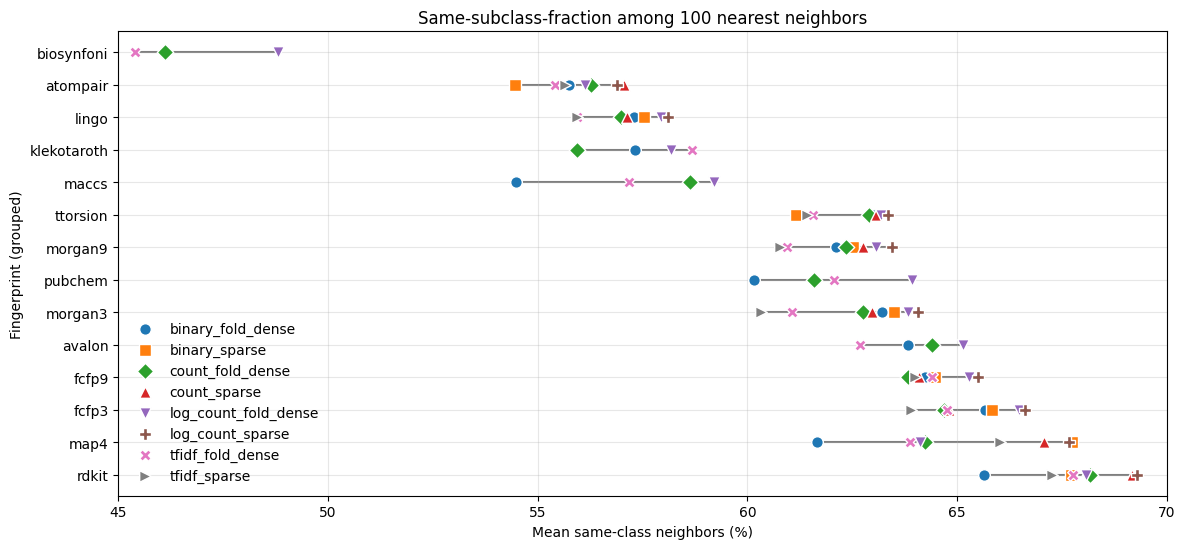

In [52]:
k=100
fig, ax = cleveland_overall_grouped(
    data, k=k,
    sort_by="max",
    title=f"Same-subclass-fraction among {k} nearest neighbors",
)
ax.set_xlim(45, 70)
plt.savefig("25_subclasses_top100_nns_allfps.png", dpi=400)
plt.savefig("25_subclasses_top100_nns_allfps.pdf")

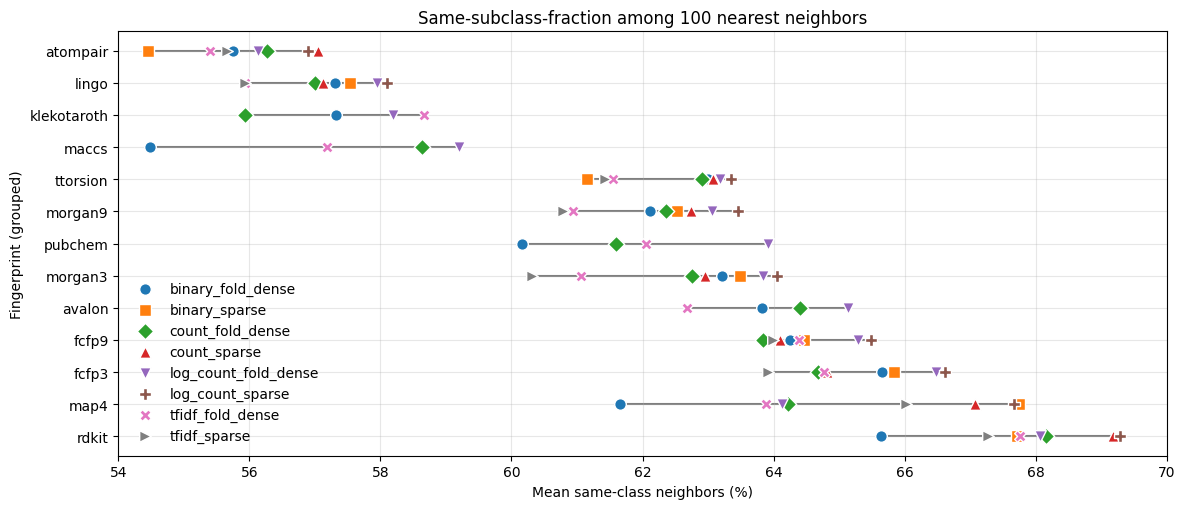

In [51]:
mask = np.array(["biosynfoni" not in x for x in data.fingerprint.values])

k=100
fig, ax = cleveland_overall_grouped(
    data[mask], k=k,
    sort_by="max",
    title=f"Same-subclass-fraction among {k} nearest neighbors",
)
ax.set_xlim(54, 70)
plt.savefig("25_subclasses_top100_nns_wo_biosynfoni.png", dpi=400)
plt.savefig("25_subclasses_top100_nns_wo_biosynfoni.pdf")

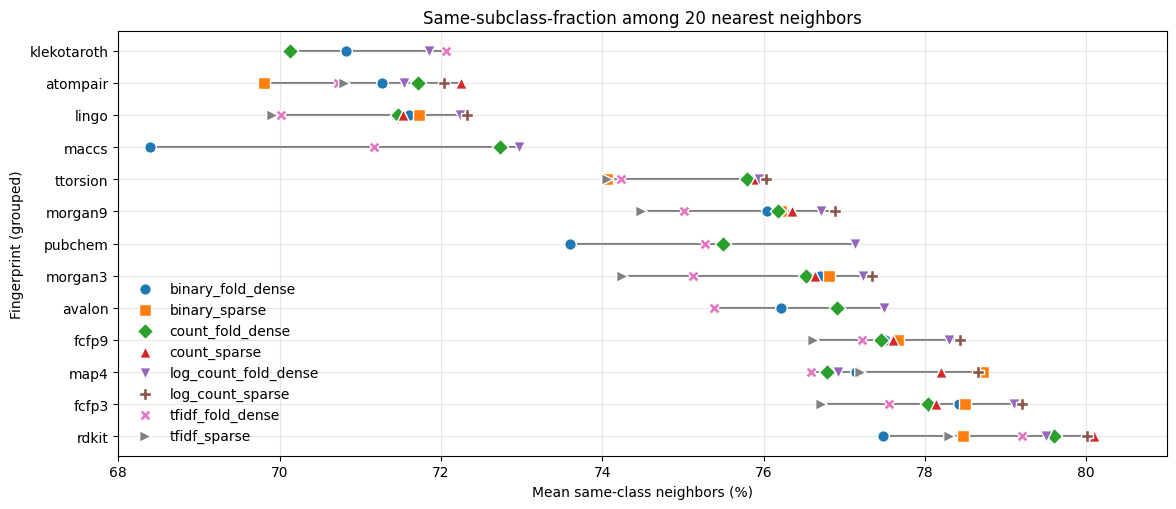

In [94]:
mask = np.array(["biosynfoni" not in x for x in data.fingerprint.values])

k=20
fig, ax = cleveland_overall_grouped(
    data[mask], k=k,
    sort_by="max",
    title=f"Same-subclass-fraction among {k} nearest neighbors",
)
ax.set_xlim(68, 81)
plt.savefig(f"25_subclasses_top{k}_nns_wo_biosynfoni.png", dpi=400)
plt.savefig(f"25_subclasses_top{k}_nns_wo_biosynfoni.pdf")

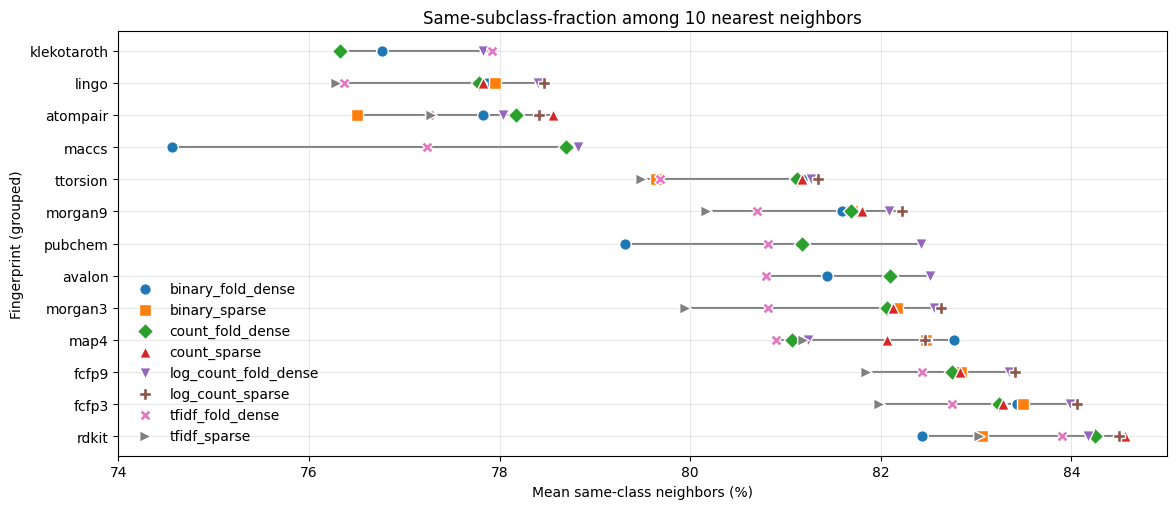

In [90]:
mask = np.array(["biosynfoni" not in x for x in data.fingerprint.values])

k=10
fig, ax = cleveland_overall_grouped(
    data[mask], k=k,
    sort_by="max",
    title=f"Same-subclass-fraction among {k} nearest neighbors",
)
ax.set_xlim(74, 85)
plt.savefig(f"25_subclasses_top{k}_nns_wo_biosynfoni.png", dpi=400)
plt.savefig(f"25_subclasses_top{k}_nns_wo_biosynfoni.pdf")

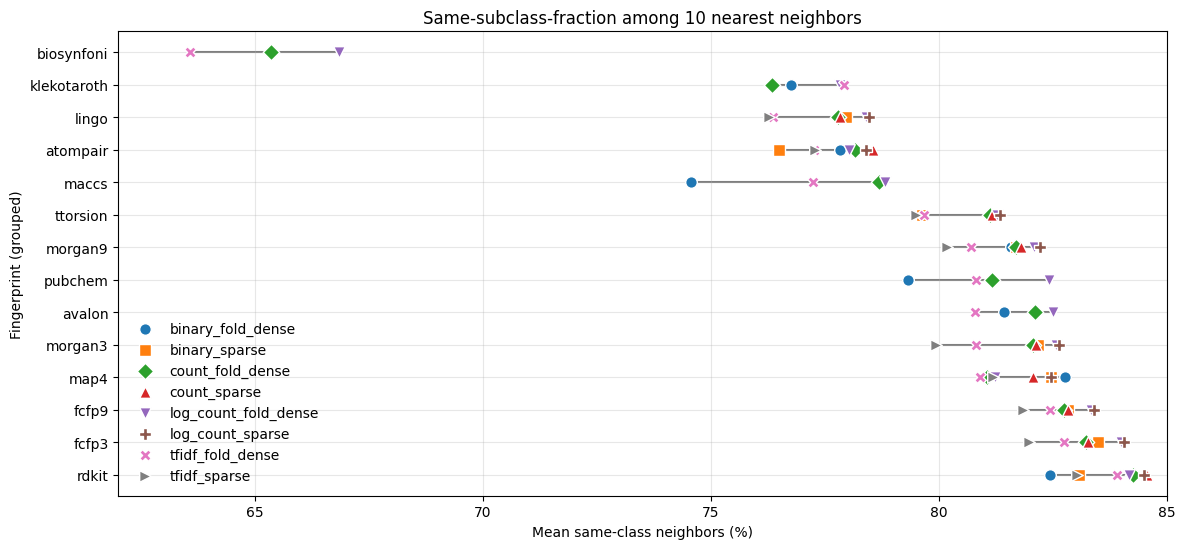

In [85]:
k=10
fig, ax = cleveland_overall_grouped(
    data, k=k,
    sort_by="max",
    title=f"Same-subclass-fraction among {k} nearest neighbors",
)
ax.set_xlim(62, 85)
plt.savefig(f"25_subclasses_top{k}_nns_allfps.png", dpi=400)
plt.savefig(f"25_subclasses_top{k}_nns_allfps.pdf")

# Subclass specific evaluation

In [65]:

def cleveland_per_subclass(
    results: pd.DataFrame,
    *,
    variant: str,
    k: int = 20,
    fingerprints: list[str] | None = None,
    sort_by: str = "mean",  # "mean" or a specific fingerprint name
    title: str | None = None,
    cmap: str = "tab10",
):
    df = results.copy()
    df = df[(df["scope"] == "per_class") & (df["variant"] == variant) & (df["k"] == k)].copy()
    df = df.dropna(subset=["label", "mean_same_class_pct"])
    df["label"] = df["label"].astype(str)

    if fingerprints is not None:
        df = df[df["fingerprint"].isin(fingerprints)]

    fps = sorted(df["fingerprint"].unique())
    subclasses = sorted(df["label"].unique())

    # Pivot: rows=subclass, cols=fingerprint
    piv = (
        df.pivot_table(index="label", columns="fingerprint", values="mean_same_class_pct", aggfunc="mean")
        .reindex(index=subclasses)
    )

    # Sorting
    if sort_by == "mean":
        order = piv.mean(axis=1).sort_values(ascending=True).index
    elif sort_by in piv.columns:
        order = piv[sort_by].sort_values(ascending=True).index
    else:
        order = piv.mean(axis=1).sort_values(ascending=True).index

    piv = piv.loc[order]

    # Plot positions
    y_pos = np.arange(piv.shape[0])

    fig, ax = plt.subplots(figsize=(14, max(6, 0.28 * piv.shape[0])))

    # Connectors: min-max across fingerprints per subclass (nice Cleveland touch)
    row_min = piv.min(axis=1).to_numpy()
    row_max = piv.max(axis=1).to_numpy()
    ax.hlines(y=y_pos, xmin=row_min, xmax=row_max, alpha=0.5, zorder=2)

    # Points per fingerprint
    cmap = plt.get_cmap(cmap)
    fp_color = {fp: cmap(i % piv.shape[0]) for i, fp in enumerate(fps)}

    for fp in fps:
        x = piv[fp].to_numpy()
        ax.scatter(x, y_pos, label=fp, s=30, alpha=0.9, color=fp_color[fp], zorder=3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(piv.index.tolist())
    ax.invert_yaxis()  # top = best if you sorted descending; we sorted ascending, so invert to see best at top? choose:
    # If you want best at top, sort descending then invert; currently ascending+invert => best at top.

    ax.set_xlim(0, 100)
    ax.set_xlabel("Mean same-class neighbors (%)")
    ax.set_ylabel("Subclass")

    if title is None:
        title = f"Cleveland plot by Subclass — variant='{variant}', k={k}"
    ax.set_title(title)

    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(frameon=False, loc="lower left")
    plt.tight_layout()
    return fig, ax


In [68]:
data.variant.value_counts()

variant
count_fold_dense        4368
log_count_fold_dense    4368
tfidf_fold_dense        4368
binary_fold_dense       4056
binary_sparse           2808
count_sparse            2808
log_count_sparse        2808
tfidf_sparse            2808
Name: count, dtype: int64

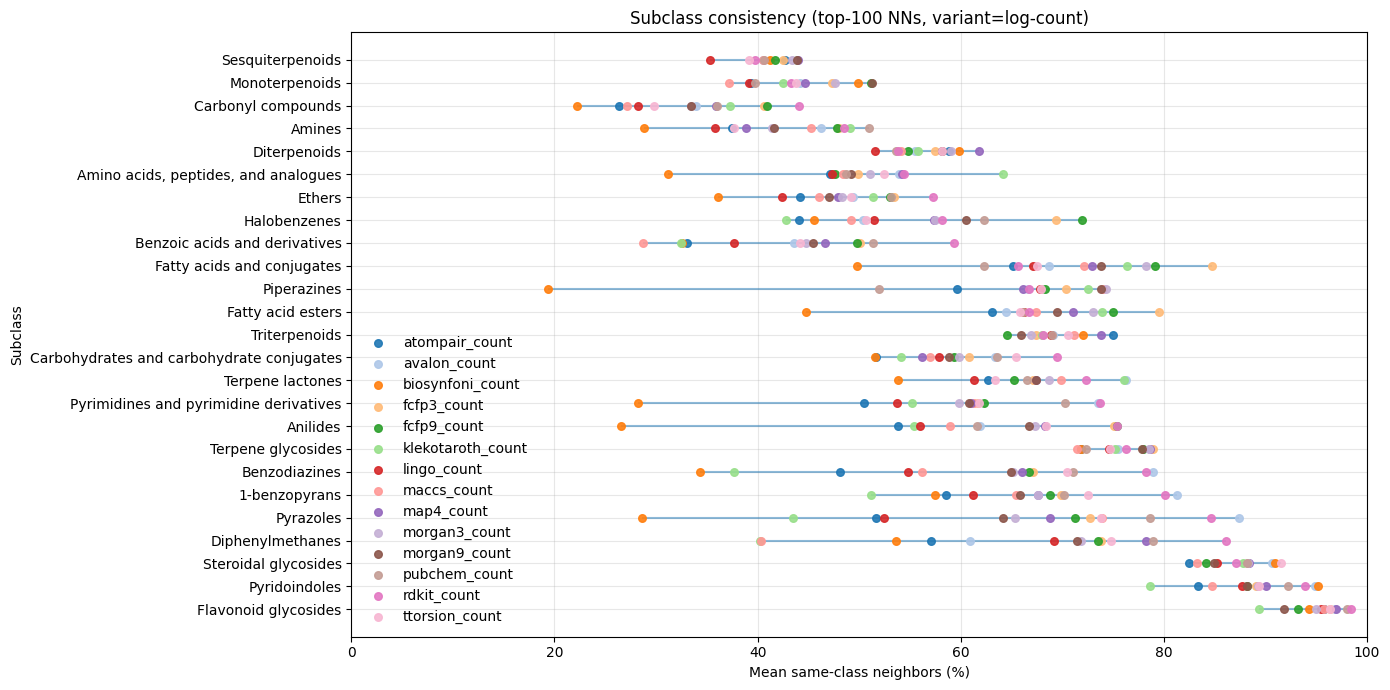

In [70]:
k=100

cleveland_per_subclass(
    data, variant="log_count_fold_dense",
    k=k,
    cmap="tab20",
    #fingerprints=["fragfp_8192_max20", "rdkit", "fragfp", "fragfp_max12"],
    sort_by="rdkit_count", #"fcfp9_count"
    title=f"Subclass consistency (top-{k} NNs, variant=log-count)",
)
plt.savefig("25_subclasses_per_class_consistency_top100_log_count.png", dpi=400)
plt.show()

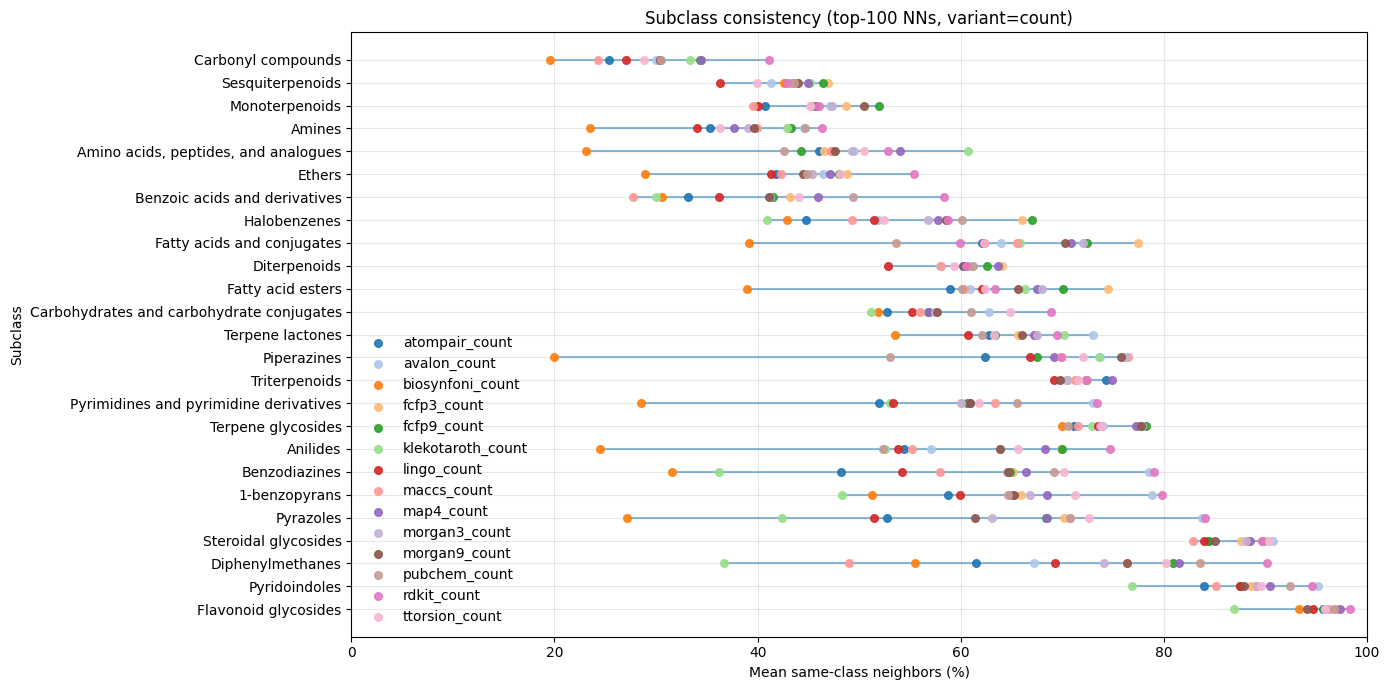

In [71]:
k=100

cleveland_per_subclass(
    data, variant="count_fold_dense",
    k=k,
    cmap="tab20",
    #fingerprints=["fragfp_8192_max20", "rdkit", "fragfp", "fragfp_max12"],
    sort_by="rdkit_count", #"fcfp9_count"
    title=f"Subclass consistency (top-{k} NNs, variant=count)",
)
plt.savefig("25_subclasses_per_class_consistency_top100_count.png", dpi=400)
plt.show()

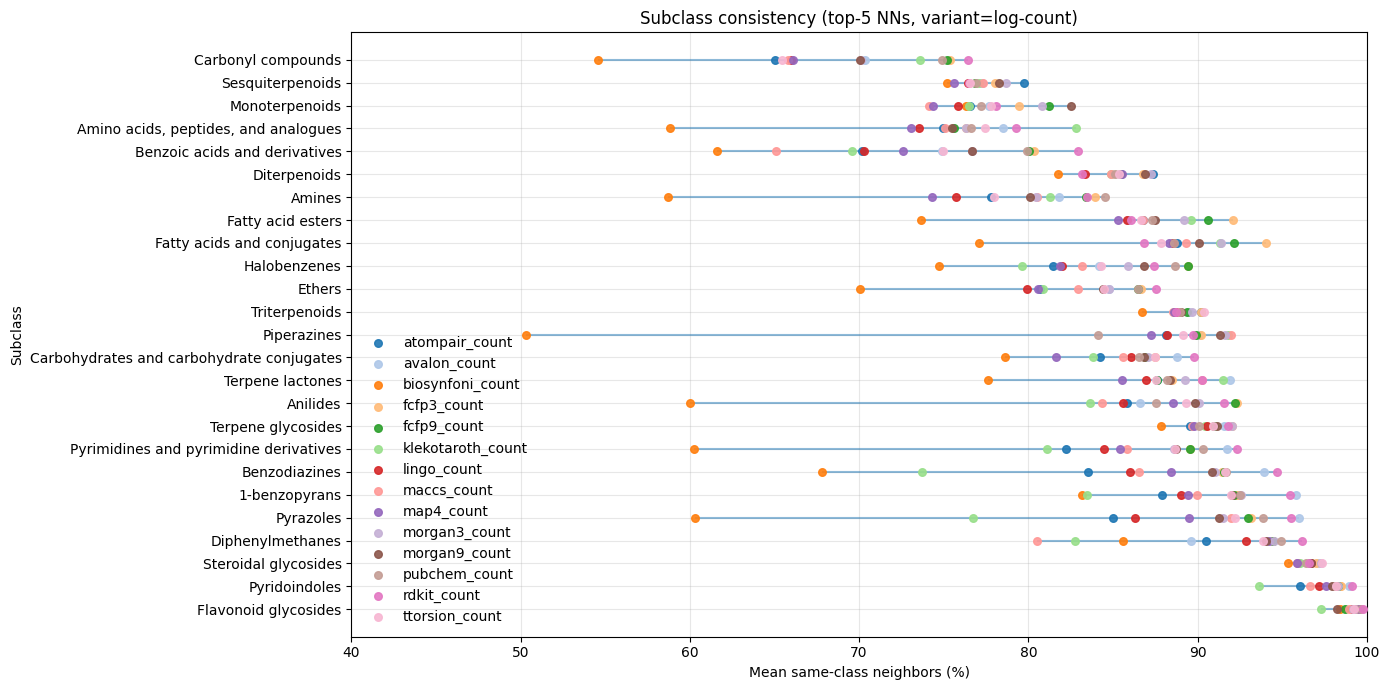

In [74]:
k=5

cleveland_per_subclass(
    data, variant="log_count_fold_dense",
    k=k,
    cmap="tab20",
    #fingerprints=["fragfp_8192_max20", "rdkit", "fragfp", "fragfp_max12"],
    sort_by="rdkit_count", #"fcfp9_count"
    title=f"Subclass consistency (top-{k} NNs, variant=log-count)",
)
plt.xlim(40)
plt.savefig(f"25_subclasses_per_class_consistency_top{k}_log_count.png", dpi=400)
plt.show()

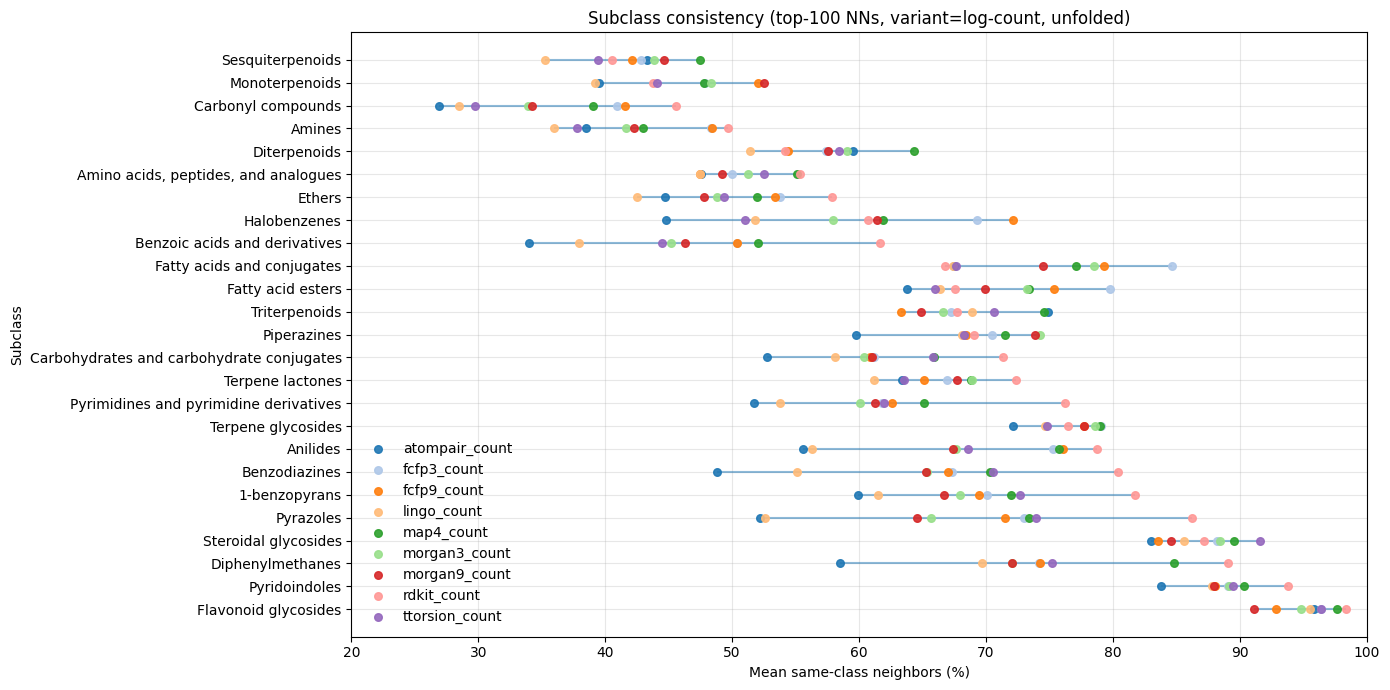

In [79]:
k=100

cleveland_per_subclass(
    data, variant="log_count_sparse",
    k=k,
    cmap="tab20",
    #fingerprints=["fragfp_8192_max20", "rdkit", "fragfp", "fragfp_max12"],
    sort_by="rdkit_count", #"fcfp9_count"
    title=f"Subclass consistency (top-{k} NNs, variant=log-count, unfolded)",
)
plt.xlim(20)
plt.savefig(f"25_subclasses_per_class_consistency_top{k}_log_count_unfolded.png", dpi=400)
plt.show()

# Inspect UMAP chem space visualizations for 25-subclasses dataset

In [22]:
from chemap.plotting import create_chem_space_umap

In [17]:
compounds

,inchikey,SMILES,Kingdom,Superclass,Class,Subclass,mass
0,QKAAFOFCOXIVQV-UHFFFAOYSA-N,CCC(C)C1C(=O)NC(C(=O)N2CCCC2C(=O)NC(C(=O)N3CCC...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",828.024
1,GXENQLUSOCKXDN-UHFFFAOYSA-N,CC(C)CC(C(=O)NC1CN(CC1=O)C(=O)C(CC(C)C)NC(=O)O...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",594.709
2,UFUVLHLTWXBHGZ-MGZQPHGTSA-N,CCCC1CC(N(C1)C)C(=O)NC(C2C(C(C(C(O2)SC)OP(=O)(...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",504.970
3,NXVSIVOMSMWEAU-UHFFFAOYSA-N,CC(C)C(C(=O)O)NC(=O)C1CSSCC(C(=O)NC(C(=O)NC(C(...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",1075.281
4,UOKQCKCIJOFELB-UHFFFAOYSA-N,CC(C(=O)NC(CCC(=O)N)C(=O)NC(CCCN=C(N)N)C(=O)NC...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",708.667
...,...,...,...,...,...,...,...
74995,QWSUTGZKTVZPRT-UHFFFAOYSA-N,C1=CC=C(C=C1)CC2=CC=CC=C2CCN,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,211.308
74996,JYHNHWMZIXPAEL-UHFFFAOYSA-N,C1=CC=C(C=C1)C(CCC#N)C2=CC=CC=C2,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,221.303
74997,MSYLETHDEIJMAF-UHFFFAOYSA-N,C1=CC=C(C=C1)C(C2=CC=CC=C2)C(=O)Cl,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,230.694
74998,DRCFCSOWKZBHDM-UHFFFAOYSA-N,CCOC(=O)COC1=CC=C(C=C1)CC2=CC=CC=C2,Organic compounds,Benzenoids,Benzene and substituted derivatives,Diphenylmethanes,270.328


In [23]:
from chemap.fingerprint_computation import FingerprintConfig

In [99]:
from chemap.plotting import create_chem_space_umap, scatter_plot_all_classes

# Systematic evaluation

In [133]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def svm_local_supervised_accuracy(
    umap_df: pd.DataFrame,
    label_col: str = "Subclass",
    xcol: str = "x",
    ycol: str = "y",
    test_size: float = 0.10,
    seeds=(0, 1, 2, 3, 4),
):
    """
    Local supervised evaluation à la Huang et al.:
    Train SVM (RBF) on 2D embedding + labels; report test accuracy.
    Repeats over multiple random seeds and returns mean/std.
    """

    # Drop missing labels/coords
    df = umap_df[[xcol, ycol, label_col]].dropna()

    X = df[[xcol, ycol]].to_numpy(dtype=float)
    y_raw = df[label_col].astype(str).to_numpy()

    # Encode labels (SVC wants discrete ints/strings; ints are convenient)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    accs = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=seed,
            stratify=y,
        )

        # scaling, assumpation: helps SVM stability
        clf = make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", gamma="scale", C=1.0)
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accs.append(accuracy_score(y_test, y_pred))

    accs = np.array(accs, dtype=float)
    return {
        "xcol": xcol,
        "ycol": ycol,
        "n": int(len(df)),
        "n_classes": int(len(np.unique(y))),
        "acc_mean": float(accs.mean()),
        "acc_std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
        "accs": accs,  # keep if you want per-seed numbers
    }



In [172]:
trials = {
    #"umap_morgan3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", False),
    "umap_fcfp3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, True),
    "umap_fcfp3_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, False),
    "umap_fcfp3_count": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, True),
    "umap_fcfp3_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    "umap_fcfp3_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", True),
    "umap_fcfp3_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", False),
    "umap_fcfp3_tfidf_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    
    "umap_fcfp9_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, True),
    "umap_fcfp9_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, False),
    "umap_fcfp9_count": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, True),
    "umap_fcfp9_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    "umap_fcfp9_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", True),
    "umap_fcfp9_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", False),
    "umap_fcfp9_tfidf_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    
    "umap_morgan9_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, False),
    "umap_morgan9_count": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, False),
    "umap_morgan9_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, "log", False),
    "umap_morgan9_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, True),
    "umap_morgan9_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, True),
    "umap_morgan9_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, "log", True),

    "umap_morgan3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, False),
    "umap_morgan3_count": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, False),
    "umap_morgan3_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", False),
    "umap_morgan3_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, True),
    "umap_morgan3_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, True),
    "umap_morgan3_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", True),

    "umap_rdkit_binary": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), False, None, True),
    "umap_rdkit_count_sparse": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, None, False),
    "umap_rdkit_count": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, None, True),
    "umap_rdkit_logcount": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, "log", True),
    "umap_rdkit_logcount_sparse": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, "log", False),
    
    "umap_map4_binary": (MAP4FPGen(dimensions=4096, radius=2), False, None, True),
    "umap_map4_binary_sparse": (MAP4FPGen(dimensions=4096, radius=2), False, None, True),
    "umap_map4_count": (MAP4FPGen(dimensions=4096, radius=2), True, None, True),
    "umap_map4_count_sparse": (MAP4FPGen(dimensions=4096, radius=2), True, None, False),
    "umap_map4_logcount": (MAP4FPGen(dimensions=4096, radius=2), True, "log", True),
    "umap_map4_logcount_sparse": (MAP4FPGen(dimensions=4096, radius=2), True, "log", False),
    
    "umap_avalon_binary": (AvalonFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, True),
    "umap_avalon_count": (AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, True),
    "umap_avalon_logcount": (AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", True),

    "umap_ttorsion_binary": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), False, None, True),
    "umap_ttorsion_count": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, None, True),
    "umap_ttorsion_logcount": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, "log", True),
    "umap_ttorsion_binary_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), False, None, False),
    "umap_ttorsion_count_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, None, False),   
    "umap_ttorsion_logcount_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, "log", False),  

    "umap_atompair_binary": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), False, None, True),
    "umap_atompair_count": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, None, True),
    "umap_atompair_logcount": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, "log", True),
    "umap_atompair_binary_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), False, None, False),
    "umap_atompair_count_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, None, False),
    "umap_atompair_logcount_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, "log", False),  
    
    "umap_lingo_binary": (LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, True),
    "umap_lingo_count": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, True),    
    "umap_lingo_logcount": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", True),    
    "umap_lingo_binary_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, False),
    "umap_lingo_count_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, False),    
    "umap_lingo_logcount_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", False),  

    "umap_maccs_logcount": (MACCSFingerprint(count=True, sparse=False), True, "log", True),
    "umap_maccs_binary": (MACCSFingerprint(count=False, sparse=False), False, None, True),
    "umap_maccs_count": (MACCSFingerprint(count=True, sparse=False), True, None, True),

    "umap_pubchem_count": (PubChemFingerprint(count=True, sparse=False), True, None, True),
    "umap_pubchem_binary": (PubChemFingerprint(count=False, sparse=False), False, None, True),
    "umap_pubchem_logcount": (PubChemFingerprint(count=True, sparse=False), True, "log", True),
    "umap_klekotaroth_binary": (KlekotaRothFingerprint(count=False, sparse=False), False, None, True),
    "umap_klekotaroth_count": (KlekotaRothFingerprint(count=True, sparse=False), True, None, True),
    "umap_klekotaroth_logcount": (KlekotaRothFingerprint(count=True, sparse=False), True, "log", True),
    "umap_biosynfoni_count": (BiosynfoniTransformer(sparse=False, n_jobs=-1), True, None, True),
    "umap_biosynfoni_logcount": (BiosynfoniTransformer(sparse=False, n_jobs=-1), True, "log", True),
}

In [173]:
for k, v in trials.items():
    out_csv = os.path.join(path_results, f"{k}_25_subclasses.csv")
    if os.path.exists(out_csv):
        print(f"----- Found existing UMAP CSV: {out_csv} (skipping) -----")
        continue

    fpgen, count, scaling, folded = v
    print(f"{k} -- count: {count} -- scaling: {scaling} -- folded: {folded}")

    config = FingerprintConfig(
        count=count,
        folded=folded,
        return_csr=False,
        invalid_policy="raise",
        scaling=scaling,
    )

    umap_df = create_chem_space_umap(
        compounds,
        col_smiles="SMILES",
        fpgen=fpgen,
        fingerprint_config=config,
        umap_random_state=None,
        n_neighbors=100,
        log_count=False,  # avoid double-log if your scaling already does it
    )
    umap_df.to_csv(out_csv, index=False)
    print(f"----- Saved: {out_csv} -----")
    


# --- load existing summary if present ---
out_summary = os.path.join(path_results, "svm_local_supervised_eval_summary.csv")

if os.path.exists(out_summary):
    existing_summary_df = pd.read_csv(out_summary)
    done_experiments = set(existing_summary_df["experiment"].astype(str))
    summary_rows = existing_summary_df.to_dict(orient="records")
    print(f"----- Found existing summary with {len(done_experiments)} experiments -----")
else:
    done_experiments = set()
    summary_rows = []
    print("----- No existing summary found (starting fresh) -----")

# --- evaluate only missing experiments ---
for k in trials.keys():
    if k in done_experiments:
        print(f"----- SVM already computed for {k} (skipping) -----")
        continue

    csv_path = os.path.join(path_results, f"{k}_25_subclasses.csv")
    if not os.path.exists(csv_path):
        print(f"----- Missing CSV for {k}: {csv_path} (skipping eval) -----")
        continue

    umap_df = pd.read_csv(csv_path)
    if "Subclass" not in umap_df.columns:
        raise ValueError(f"{csv_path} has no 'Subclass' column. Columns: {list(umap_df.columns)}")

    print(f"Training SVM for: {k}")
    res = svm_local_supervised_accuracy(
        umap_df,
        label_col="Subclass",
        test_size=0.10,
        seeds=(10, 11, 12),
    )

    summary_rows.append({
        "experiment": k,
        "csv": csv_path,
        "n": res["n"],
        "n_classes": res["n_classes"],
        "xcol": res["xcol"],
        "ycol": res["ycol"],
        "svm_acc_mean": res["acc_mean"],
        "svm_acc_std": res["acc_std"],
        "svm_accs": ",".join(f"{a:.5f}" for a in res["accs"]),
    })

    # --- write back updated summary (and display) ---
    summary_df = pd.DataFrame(summary_rows).sort_values("svm_acc_mean", ascending=False)
    summary_df.to_csv(out_summary, index=False)

display(summary_df)  # in Jupyter
print(f"----- Saved summary: {out_summary} -----")

----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_fcfp3_binary_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_fcfp3_binary_sparse_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_fcfp3_count_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_fcfp3_count_sparse_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_fcfp3_logcount_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_s

  0%|          | 0/32 [00:00<?, ?it/s]

/home/daisy/anaconda3/envs/ms2query_2/lib/python3.12/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(


----- Saved: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_avalon_binary_25_subclasses.csv -----
umap_avalon_count -- count: True -- scaling: None -- folded: True


  0%|          | 0/32 [00:00<?, ?it/s]

...

----- Saved: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_atompair_count_sparse_25_subclasses.csv -----
umap_atompair_logcount_sparse -- count: True -- scaling: log -- folded: False


Compute fingerprints: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [00:11<00:00, 6722.20it/s]
/home/daisy/anaconda3/envs/ms2query_2/lib/python3.12/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(


----- Saved: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_atompair_logcount_sparse_25_subclasses.csv -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_lingo_binary_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_lingo_count_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_lingo_logcount_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/umap_lingo_binary_sparse_25_subclasses.csv (skipping) -----
----- Found existing UMAP CSV: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/

,experiment,csv,n,n_classes,xcol,ycol,svm_acc_mean,svm_acc_std,svm_accs
0,umap_fcfp9_logcount_sparse,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.643244,0.007220,"0.63547,0.64973,0.64453"
1,umap_map4_logcount_sparse,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.640756,0.006274,"0.63400,0.64640,0.64187"
2,umap_fcfp9_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.639911,0.005981,"0.63307,0.64413,0.64253"
3,umap_fcfp3_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.637111,0.007627,"0.63027,0.64533,0.63573"
4,umap_fcfp3_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.636578,0.002405,"0.63427,0.63640,0.63907"
...,...,...,...,...,...,...,...,...,...
49,umap_klekotaroth_count,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.433689,0.003012,"0.43653,0.43400,0.43053"
50,umap_pubchem_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.422911,0.001600,"0.42393,0.42373,0.42107"
51,umap_maccs_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.420178,0.005626,"0.42080,0.42547,0.41427"
52,umap_biosynfoni_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.407022,0.003478,"0.40840,0.40960,0.40307"


----- Saved summary: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity/svm_local_supervised_eval_summary.csv -----


In [174]:
summary_df

,experiment,csv,n,n_classes,xcol,ycol,svm_acc_mean,svm_acc_std,svm_accs
0,umap_fcfp9_logcount_sparse,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.643244,0.007220,"0.63547,0.64973,0.64453"
1,umap_map4_logcount_sparse,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.640756,0.006274,"0.63400,0.64640,0.64187"
2,umap_fcfp9_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.639911,0.005981,"0.63307,0.64413,0.64253"
3,umap_fcfp3_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.637111,0.007627,"0.63027,0.64533,0.63573"
4,umap_fcfp3_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.636578,0.002405,"0.63427,0.63640,0.63907"
...,...,...,...,...,...,...,...,...,...
49,umap_klekotaroth_count,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.433689,0.003012,"0.43653,0.43400,0.43053"
50,umap_pubchem_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.422911,0.001600,"0.42393,0.42373,0.42107"
51,umap_maccs_binary,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.420178,0.005626,"0.42080,0.42547,0.41427"
52,umap_biosynfoni_logcount,/home/daisy/Florian/molecular_fingerprint_comp...,75000,25,x,y,0.407022,0.003478,"0.40840,0.40960,0.40307"


In [176]:
import os
import re
from typing import Mapping, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chemap.plotting import cleveland_dotplot, ClevelandStyle


# --- appearance mapping ---
SETTING_COLORS = {
    "binary":   "crimson",
    "count":    "teal",
    "logcount": "dodgerblue",
    "tfidf":    "darkorange",
}

VARIANT_MARKERS = {
    "folded":   "o",   # default / dense
    "unfolded": "^",   # sparse -> unfolded
    "fixed":    "s",
}

FIXED_SIZED_FPS = ["maccs", "pubchem", "klekotaroth", "biosynfoni", "element"]


# --- parsing helpers (same spirit as your existing code) ---
def _setting_from_name(name: str) -> str:
    """Extract setting token from experiment name (binary/count/logcount/tfidf)."""
    name = str(name)
    # look for token boundaries to avoid accidental matches
    for tok in ["logcount", "count", "tfidf", "binary"]:
        if re.search(rf"(^|_){tok}($|_)", name):
            return tok
    return "binary"


def _is_sparse(name: str) -> bool:
    return bool(re.search(r"(^|_)sparse($|_)", str(name)))


def _is_fixed(name: str) -> bool:
    s = str(name)
    return any(fp in s for fp in FIXED_SIZED_FPS)


def _family_key(name: str) -> str:
    """
    Get fingerprint family/key from experiment name.
    Examples:
      umap_morgan3_binary         -> morgan3
      umap_fcfp9_logcount_sparse  -> fcfp9
      chemap_lingo_count          -> lingo
    """
    n = str(name)

    # strip leading umap_ if present
    n = re.sub(r"^umap_", "", n)

    # special cases
    if n.startswith("chemap_lingo_") or n == "chemap_lingo":
        return "lingo"

    # remove trailing tokens (_binary/_count/_logcount/_tfidf) and optional _sparse
    n = re.sub(r"(_sparse)$", "", n)
    n = re.sub(r"_(binary|count|logcount|tfidf)$", "", n)

    # also remove stray "chemap" if present
    n = n.replace("chemap_", "").replace("chemap", "")
    return n.strip("_")


def _clean_label(s: str) -> str:
    return str(s).replace("_", " ").replace("chemap ", "").strip()


# --- main plot function ---
def plot_svm_acc_comparison_cleveland(
    summary_csv_or_df,
    *,
    title: str = "Local supervised evaluation (SVM on 2D UMAP)",
    filename: Optional[str] = None,
    connect: bool = True,
    row_range: bool = True,
    xlabel: str = "SVM accuracy on Superclass (mean over seeds)",
    style: "ClevelandStyle" = None,
    experiment_col: str = "experiment",
    x_col: str = "svm_acc_mean",
) -> Tuple["plt.Figure", "plt.Axes"]:
    """
    Plot SVM local-supervised evaluation scores from svm_local_supervised_eval_summary.csv.

    - row            = fingerprint family (morgan3, fcfp9, lingo, ...)
    - color_group    = setting (binary/count/logcount/tfidf)
    - marker_group   = variant (folded/unfolded/fixed) where sparse -> unfolded
    - x              = svm_acc_mean
    """
    if style is None:
        style = ClevelandStyle()

    # Load
    if isinstance(summary_csv_or_df, (str, os.PathLike)):
        df = pd.read_csv(summary_csv_or_df)
    else:
        df = summary_csv_or_df.copy()

    if experiment_col not in df.columns or x_col not in df.columns:
        raise ValueError(f"Need columns '{experiment_col}' and '{x_col}'. Got: {list(df.columns)}")

    df = df.dropna(subset=[experiment_col, x_col]).copy()

    # Build tidy arrays (one point per experiment)
    rows, xs, color_group, marker_group, connect_group = [], [], [], [], []

    for name, x in zip(df[experiment_col].astype(str), df[x_col].astype(float)):
        setting = _setting_from_name(name)
        family = _family_key(name)

        if _is_fixed(name):
            variant = "fixed"
        elif _is_sparse(name):
            variant = "unfolded"   # <- rename sparse to unfolded
        else:
            variant = "folded"

        rows.append(family)
        xs.append(float(x))
        color_group.append(setting)
        marker_group.append(variant)
        connect_group.append(setting)  # connect within same (family, setting)

    if not rows:
        raise ValueError("No rows to plot (empty summary after filtering).")

    # Row order: best-performing family on top (max accuracy), then invert_yaxis
    best_by_family = {}
    for r, xv in zip(rows, xs):
        best_by_family[r] = max(best_by_family.get(r, float("-inf")), float(xv))
    row_order = sorted(best_by_family.keys(), key=lambda r: best_by_family[r], reverse=True)

    # Plot
    fig, ax = cleveland_dotplot(
        row=rows,
        x=xs,
        color_group=color_group,
        marker_group=marker_group,
        connect_group=connect_group,

        row_order=row_order,
        row_label_fn=_clean_label,

        color_map=SETTING_COLORS,
        marker_map=VARIANT_MARKERS,
        marker_zorder={"unfolded": 4, "folded": 3, "fixed": 4},

        title=title,
        xlabel=xlabel,

        connect=connect,
        row_range=row_range,
        show_zero_line_if_needed=False,

        color_legend_title="Bit mode",
        marker_legend_title="Variant",
        color_legend_position="upper left",
        style=style,
    )

    ax.set_ylabel("Fingerprint type")
    ax.invert_yaxis()
    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=450, bbox_inches="tight")

    plt.show()
    return fig, ax


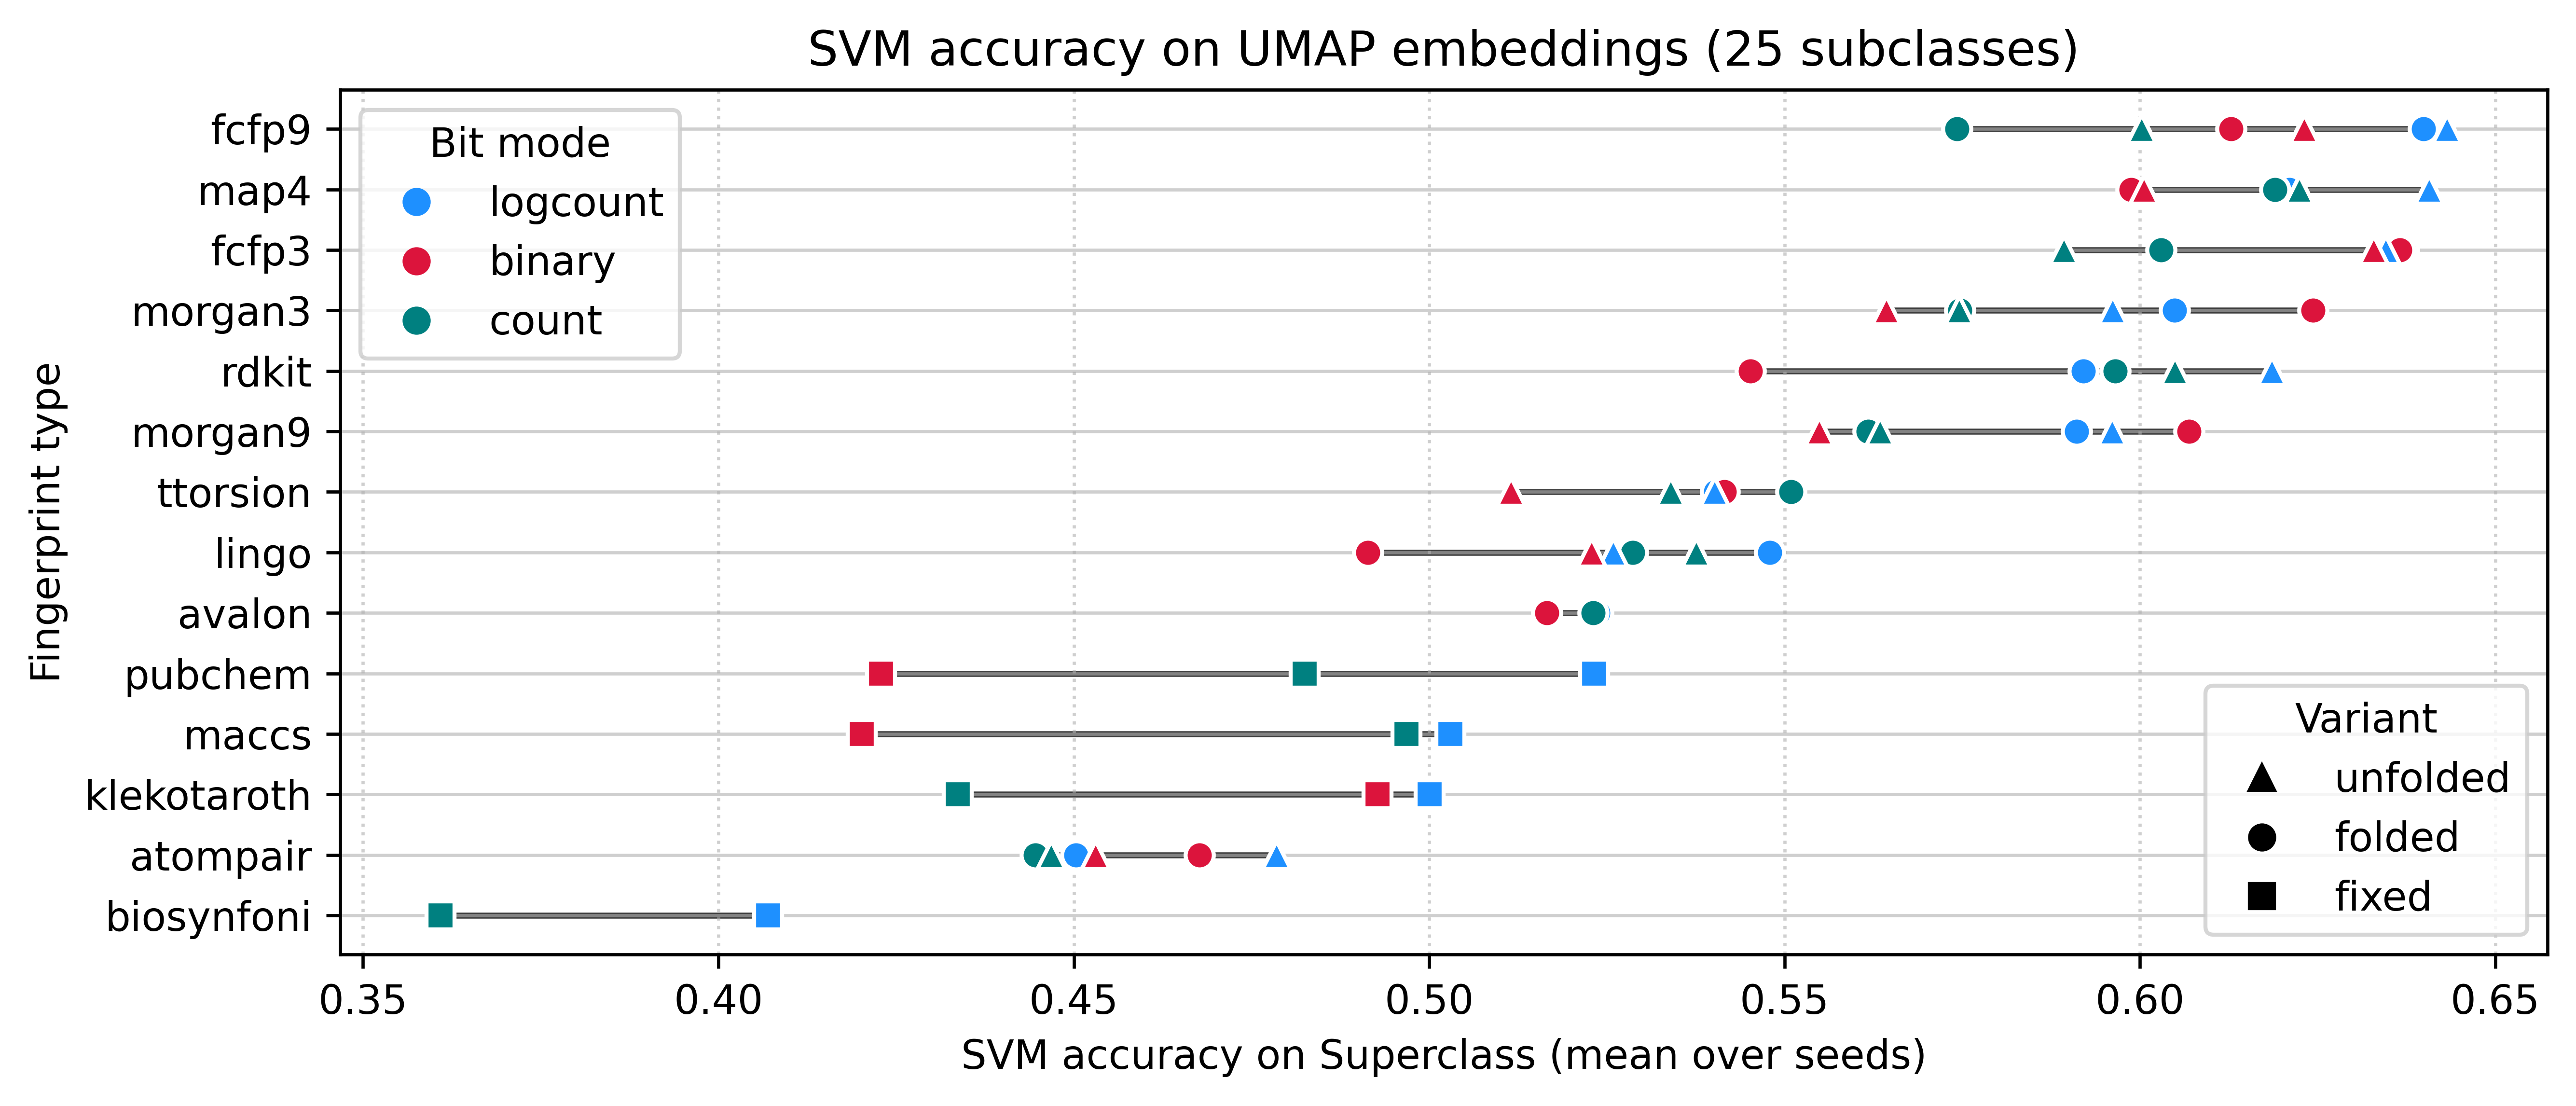

In [184]:
summary_path = os.path.join(path_results, "svm_local_supervised_eval_summary.csv")
x = plot_svm_acc_comparison_cleveland(
    summary_path,
    title="SVM accuracy on UMAP embeddings (25 subclasses)",
    filename=os.path.join(path_results, "svm_acc_cleveland_summary.png"),
    connect=False,
)

# Plot all UMAPs

In [ ]:
trials = {
    #"umap_morgan3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", False),
    "umap_fcfp3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, True),
    "umap_fcfp3_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, False),
    "umap_fcfp3_count": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, True),
    "umap_fcfp3_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    "umap_fcfp3_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", True),
    "umap_fcfp3_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", False),
    #"umap_fcfp3_tfidf_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    
    "umap_fcfp9_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, True),
    "umap_fcfp9_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False, None, False),
    "umap_fcfp9_count": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, True),
    "umap_fcfp9_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    "umap_fcfp9_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", True),
    "umap_fcfp9_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, "log", False),
    #"umap_fcfp9_tfidf_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True, None, False),
    
    "umap_morgan9_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, False),
    "umap_morgan9_count": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, False),
    "umap_morgan9_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, "log", False),
    "umap_morgan9_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, True),
    "umap_morgan9_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, None, True),
    "umap_morgan9_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True, "log", True),

    "umap_morgan3_binary": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, False),
    "umap_morgan3_count": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, False),
    "umap_morgan3_logcount": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", False),
    "umap_morgan3_binary_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, True),
    "umap_morgan3_count_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, None, True),
    "umap_morgan3_logcount_sparse": (rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True, "log", True),

    "umap_rdkit_binary": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), False, None, True),
    "umap_rdkit_count_sparse": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, None, False),
    "umap_rdkit_count": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, None, True),
    "umap_rdkit_logcount": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, "log", True),
    "umap_rdkit_logcount_sparse": (rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096), True, "log", False),
    
    "umap_map4_binary": (MAP4FPGen(dimensions=4096, radius=2), False, None, True),
    "umap_map4_binary_sparse": (MAP4FPGen(dimensions=4096, radius=2), False, None, True),
    "umap_map4_count": (MAP4FPGen(dimensions=4096, radius=2), True, None, True),
    "umap_map4_count_sparse": (MAP4FPGen(dimensions=4096, radius=2), True, None, False),
    "umap_map4_logcount": (MAP4FPGen(dimensions=4096, radius=2), True, "log", True),
    "umap_map4_logcount_sparse": (MAP4FPGen(dimensions=4096, radius=2), True, "log", False),
    
    "umap_avalon_binary": (AvalonFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, True),
    "umap_avalon_count": (AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, True),
    "umap_avalon_logcount": (AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", True),

    "umap_ttorsion_binary": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), False, None, True),
    "umap_ttorsion_count": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, None, True),
    "umap_ttorsion_logcount": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, "log", True),
    "umap_ttorsion_binary_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), False, None, False),
    "umap_ttorsion_count_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, None, False),   
    "umap_ttorsion_logcount_sparse": (rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=4096), True, "log", False),  

    "umap_atompair_binary": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), False, None, True),
    "umap_atompair_count": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, None, True),
    "umap_atompair_logcount": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, "log", True),
    "umap_atompair_binary_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), False, None, False),
    "umap_atompair_count_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, None, False),
    "umap_atompair_logcount_sparse": (rdFingerprintGenerator.GetAtomPairGenerator(fpSize=4096), True, "log", False),  
    
    "umap_lingo_binary": (LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, True),
    "umap_lingo_count": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, True),    
    "umap_lingo_logcount": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", True),    
    "umap_lingo_binary_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False, None, False),
    "umap_lingo_count_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, None, False),    
    "umap_lingo_logcount_sparse": (LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True, "log", False),  

    "umap_maccs_logcount": (MACCSFingerprint(count=True, sparse=False), True, "log", True),
    "umap_maccs_binary": (MACCSFingerprint(count=False, sparse=False), False, None, True),
    "umap_maccs_count": (MACCSFingerprint(count=True, sparse=False), True, None, True),

    "umap_pubchem_count": (PubChemFingerprint(count=True, sparse=False), True, None, True),
    "umap_pubchem_binary": (PubChemFingerprint(count=False, sparse=False), False, None, True),
    "umap_pubchem_logcount": (PubChemFingerprint(count=True, sparse=False), True, "log", True),
    "umap_klekotaroth_binary": (KlekotaRothFingerprint(count=False, sparse=False), False, None, True),
    "umap_klekotaroth_count": (KlekotaRothFingerprint(count=True, sparse=False), True, None, True),
    "umap_klekotaroth_logcount": (KlekotaRothFingerprint(count=True, sparse=False), True, "log", True),
    "umap_biosynfoni_count": (BiosynfoniTransformer(sparse=False, n_jobs=-1), True, None, True),
    "umap_biosynfoni_logcount": (BiosynfoniTransformer(sparse=False, n_jobs=-1), True, "log", True),
}


path_results = r"/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/25_subclass_knn_similarity"

for k, v in trials.items():
    fpgen, count, scaling, folded = v
    print(f"{k} -- count: {count} -- scaling: {scaling} -- folded: {folded}")

    if os.path.exists(os.path.join(path_results, f"{k}_25_subclasses.png")):
        print("skipping................")
        continue

    umap_df = pd.read_csv(os.path.join(path_results, f"{k}_25_subclasses.csv"))

    fig, ax, p = scatter_plot_all_classes(
        umap_df,
        palette_or_cmap="turbo_r",
        legend_frameon=True,
        #display_legend=False,
        legend_outside=True,
        figsize=(30, 20),
        title=k,
    )
    plt.savefig(os.path.join(path_results, f"{k}_25_subclasses.png"), dpi=300)
    plt.savefig(os.path.join(path_results, f"{k}_25_subclasses.pdf"))